# DIMER Notebook: Weather and Earth-System Forecasting with Aurora

**Profile:** `E2E`  
**Mode:** `WORKSHOP`  
**Notebook specification:** `2.1`  
**Status:** Candidate  
**Canonical runtime:** NVIDIA Tesla T4 or equivalent

This standalone notebook demonstrates **short-range global weather forecasting** with Microsoft's Aurora Earth-system foundation model.

The learning workflow is:

> **ERA5 analysis → persistence baseline → frozen Aurora → diagnose resolution/domain shift → bounded LoRA adaptation → validation selection → freeze → independent 6/12/18/24-hour test → spatial interpretation → new-origin forecast → adapter export and fresh reload**

### Core lesson

A foundation model is not automatically useful merely because it is pretrained.

Aurora was trained at **0.25°** resolution. This notebook deliberately uses real ERA5 reanalysis at **1.5°**, six times coarser along each horizontal axis. At that out-of-distribution resolution, the small frozen checkpoint can lose to a very simple persistence forecast. The notebook then asks whether a **540,672-parameter LoRA adaptation** can recover useful short-range skill.

### Weather, not climate projection

This notebook forecasts atmospheric state over **6–24 hours**. It does **not** perform:

- climate projection;
- seasonal climate outlooks;
- long-range climate simulation; or
- climate-change attribution.

Weather forecasting predicts how an atmospheric initial condition evolves over hours to days. Climate projection studies statistical changes in the Earth system over much longer periods and under changing forcings.

### Standalone contract

The default path:

- does not clone a Git repository;
- does not download or import DIMER repository source;
- does not call DIMER workers or APIs;
- requires no token or login;
- uses the upstream `microsoft-aurora` Python package directly;
- pins the Aurora model revision and checkpoint digest;
- obtains real public ERA5/WeatherBench2 data anonymously;
- runs validation, forecasting, LoRA adaptation, evaluation, export, and reload locally.

The notebook is marked **candidate** because its lighter xarray/GCS acquisition path does not yet reproduce the current Aurora pipeline's 57-object per-file digest verification. Exact WeatherBench2 object-pin parity remains a release qualification item.

All measurements are **tutorial/sample-sanity evidence**, not operational forecast verification.

**AI Use Disclosure:** Generative AI assisted with this notebook’s code and instructional content under maintainer direction. The maintainer remains responsible for review, validation, and release decisions. AI-generated material may contain errors; validation claims are limited to documented runs and configurations. AI use does not imply independent verification, provider endorsement, or release approval.

## How to use this notebook

**Who it is for.** Learners who can run Python cells in Colab/Jupyter and have basic familiarity with arrays/plots; prior numerical-weather-prediction experience is not required.

**Runtime.** A capable CUDA GPU is required for the canonical Aurora path; follow the resource envelope stated in the notebook.

**How to run it.**
1. Select the documented runtime/accelerator.
2. Choose **Run all** for the canonical path; the defaults are the reference settings.
3. Read the explanation around each learning stage while the cells execute.
4. Cells marked **Infrastructure** handle setup, model acquisition, provenance, or orchestration. You may run those cells without understanding their implementation.

### Task at a glance

`historical Earth-system state → Aurora forecast rollout → future atmospheric/surface state → comparison with ERA5 truth and persistence`

### Roadmap

1. Understand the task, inputs, outputs, and evaluation boundary.
2. Inspect and validate the built-in sample.
3. Establish the simple reference/baseline where applicable.
4. Run the model or model comparison.
5. Inspect errors, disagreements, robustness, or resource tradeoffs.
6. Try one controlled change and explain what changed.
7. Write an evidence-based conclusion, then optionally try your own compatible data.

### What successful execution looks like

You should finish with validated sample/input evidence, the notebook's principal baseline/reference result, model outputs and comparison metrics, at least one diagnostic or qualitative view, and machine-readable results/provenance where the capability supports them. Exact numeric values may vary slightly with the supported runtime; interpret the pattern and the stated metric semantics rather than treating one number as universal.


## 0. Learning objectives and resource envelope

By the end of this notebook you should be able to:

1. describe an Aurora atmospheric state;
2. distinguish surface, pressure-level, and static Earth variables;
3. explain why Aurora needs two historical analyses;
4. construct an autoregressive 6–24-hour rollout;
5. implement a persistence baseline;
6. calculate cosine-latitude-weighted global RMSE;
7. read RMSE ratio relative to persistence;
8. recognize resolution/domain shift;
9. perform bounded LoRA adaptation without touching the full backbone;
10. preserve train/validation/test time-window separation;
11. interpret lead-time error growth and spatial error maps;
12. export and reload a SafeTensors adapter; and
13. distinguish an experiment output from an operational weather product.

### Expected resource envelope

Approximate default-path acquisition:

- Aurora small checkpoint: **451 MB**, plus the **12 MB** upstream static-field file
- Converted base cache (section 4): about **464 MB** of local disk outside `OUTPUT_DIR`
- WeatherBench2 data actually pulled by xarray for four two-day windows: approximately **200 MB**, subject to store/chunk implementation
- Python packages and caches: additional runtime-dependent storage

The live DIMER Aurora carrier has previously completed an equivalent E2E workflow on a Tesla T4 in roughly five minutes. This candidate notebook must receive its own clean-runtime timing before release.

## 1. Runtime controls

**Lead-time controls.** `MAX_LEAD_STEPS` sets the **scored** leads (6 h each) for validation and test. A forecast origin needs two history analyses and one later analysis per lead, so each validation/test window needs `2 + MAX_LEAD_STEPS` analyses. The built-in windows have eight, so at most **6 steps (36 h)** can be scored; 42 h and 48 h are refused before any model is loaded. `FUTURE_FORECAST_STEPS` sets a separate, **unscored** forecast beyond the end of the test window (section 18), up to 48 h.

**Bring your own data (BYOD): read this before choosing paths.** BYOD replaces all four windows with your NetCDF files:
- **Roles:** two training windows, one validation window and one test window. Their analysis times must not overlap, and no analysis field may repeat across roles. Every training analysis must come before the validation window, which must come before the test window.
- **Grid:** all four windows use one regular global grid. Latitude runs 90 to −90 (either direction; uniform spacing, H mod 4 in {0, 1}). Longitude lies in [0, 360) with uniform spacing, covers the full circle, and W is divisible by 4.
- **Levels:** exactly the 13 Aurora pressure levels.
- **Static fields:** all four windows carry identical static fields.
- **Dimensions:** surface variables use (time, latitude, longitude), atmospheric variables use (time, level, latitude, longitude), and static fields use (latitude, longitude), in any order; variables are transposed by dimension name.
- **Units:** SI units as listed in section 3.
- **Length:** each window holds 3..64 six-hourly analyses, and validation/test also need `2 + MAX_LEAD_STEPS` analyses.

Section 21 gives the full schema.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [1]:
# @title Notebook controls
USE_BYOD = False                  # @param {type:"boolean"}
BYOD_TRAIN_1_PATH = ""            # @param {type:"string"}
BYOD_TRAIN_2_PATH = ""            # @param {type:"string"}
BYOD_VALIDATION_PATH = ""         # @param {type:"string"}
BYOD_TEST_PATH = ""               # @param {type:"string"}

EPOCHS = 6                        # @param {type:"integer"}
LEARNING_RATE = 0.001             # @param {type:"number"}
TRAINABLE = "lora"                # @param ["lora", "lora+heads"]
MAX_LEAD_STEPS = 4                # @param {type:"integer"}
FUTURE_FORECAST_STEPS = 4         # @param {type:"integer"}
OUTPUT_DIR = "outputs"            # @param {type:"string"}

# MAX_LEAD_STEPS: scored leads (6 h each) for validation and test. Each validation/test window needs
#   2 history analyses + MAX_LEAD_STEPS target analyses; the built-in 8-analysis windows allow at most 6 (36 h).
# FUTURE_FORECAST_STEPS: unscored forecast beyond the end of the test window (section 18), up to 8 (48 h).
# "lora+heads" also trains the encoder token embeddings, not only the decoder heads.

SEED = 0

if not 1 <= EPOCHS <= 50:
    raise ValueError("EPOCHS must be in 1..50")
if not 0 < LEARNING_RATE <= 0.1:
    raise ValueError("LEARNING_RATE must be in (0, 0.1]")
if TRAINABLE not in {"lora", "lora+heads"}:
    raise ValueError("TRAINABLE must be 'lora' or 'lora+heads'")
if not 1 <= MAX_LEAD_STEPS <= 8:
    raise ValueError("MAX_LEAD_STEPS must be in 1..8")
if not 1 <= FUTURE_FORECAST_STEPS <= 8:
    raise ValueError("FUTURE_FORECAST_STEPS must be in 1..8")

import datetime as _datetime
import os as _os
from pathlib import Path

# A fresh run identity each time this cell runs: a run starts here and continues top to bottom.
RUN_ID = _datetime.datetime.now(_datetime.timezone.utc).strftime("%Y%m%dT%H%M%SZ") + f"-{_os.getpid()}"
OUTPUT_ROOT = Path(OUTPUT_DIR)
for p in [
    OUTPUT_ROOT / "data",
    OUTPUT_ROOT / "baseline",
    OUTPUT_ROOT / "frozen_model",
    OUTPUT_ROOT / "adaptation",
    OUTPUT_ROOT / "frozen",
    OUTPUT_ROOT / "test",
    OUTPUT_ROOT / "future",
    OUTPUT_ROOT / "artifacts" / "aurora_lora",
    OUTPUT_ROOT / "figures",
    OUTPUT_ROOT / "provenance",
    OUTPUT_ROOT / "activity",
]:
    p.mkdir(parents=True, exist_ok=True)

# Every file this run writes is registered here; the report bundle (section 25) contains exactly these files,
# so outputs left in OUTPUT_DIR by earlier runs are preserved on disk but never packaged as this run's results.
PRODUCED = {}

def produced(path):
    path = Path(path)
    PRODUCED[str(path.resolve())] = path
    return path

print({
    "run_id": RUN_ID,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "trainable": TRAINABLE,
    "max_lead_hours": MAX_LEAD_STEPS * 6,
    "future_forecast_hours": FUTURE_FORECAST_STEPS * 6,
    "output_root": str(OUTPUT_ROOT.resolve()),
})

{'run_id': '20260928T214804Z-851', 'epochs': 6, 'learning_rate': 0.001, 'trainable': 'lora', 'max_lead_hours': 24, 'future_forecast_hours': 24, 'output_root': '/content/outputs'}


## 2. Install one-pass pinned runtime

The model/runtime pins follow the current live DIMER Aurora profile. This notebook additionally installs anonymous Google Cloud/Zarr readers for its simpler standalone WeatherBench2 acquisition path.

No manual kernel restart is part of the intended `Run all` path.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [2]:
# @title Install the notebook runtime
import importlib
import importlib.metadata
import os
import platform
import subprocess
import sys

PINS = [
    "torch==2.14.0",
    "microsoft-aurora==2.0.1",
    "timm==1.0.29",
    "einops==0.8.2",
    "xarray==2026.7.0",
    "netCDF4==1.7.4",
    "numcodecs==0.17.0",
    "numpy==2.5.3",
    "safetensors==0.8.0",
    "huggingface-hub==1.32.0",
    "zarr==3.4.0",
    "gcsfs==2026.7.0",
    "matplotlib>=3.9,<3.11",
    "pandas>=2.2,<3.1",
]

SKIP_INSTALL = os.environ.get("DIMER_NOTEBOOK_CI_PREINSTALLED") == "1"

# Hosted kernels such as Colab import NumPy at startup. Replacing a loaded module on disk would force a manual
# restart (Notebook Spec RUN10), so a NumPy 2.x that is already loaded is kept and recorded instead of reinstalled.
NUMPY_PRELOADED = None
if "numpy" in sys.modules and str(getattr(sys.modules["numpy"], "__version__", "")).startswith("2."):
    NUMPY_PRELOADED = sys.modules["numpy"].__version__
    PINS = [f"numpy=={NUMPY_PRELOADED}" if pin.startswith("numpy==") else pin for pin in PINS]

if not SKIP_INSTALL:
    completed = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *PINS],
        check=False, text=True, capture_output=True,
    )
    if completed.returncode != 0:
        raise RuntimeError(
            f"pip install failed with exit code {completed.returncode}.\n"
            f"--- stderr (tail) ---\n{completed.stderr[-4000:]}\n"
            f"--- stdout (tail) ---\n{completed.stdout[-2000:]}"
        )
    importlib.invalidate_caches()

# Fail closed rather than run with a module whose files were replaced underneath it.
stale = [
    (name, sys.modules[name].__version__, importlib.metadata.version(name))
    for name in ("numpy", "torch")
    if name in sys.modules
    and str(sys.modules[name].__version__).split("+")[0] != importlib.metadata.version(name).split("+")[0]
]
if stale:
    raise RuntimeError(
        "The kernel had already imported packages that the pinned install replaced on disk. "
        "Restart the Python session and choose Run all again (Colab: Runtime > Restart session; "
        f"do not delete the runtime, which discards the installed pins). Stale modules: {stale}"
    )
print("numpy:", "preloaded by the host kernel" if NUMPY_PRELOADED else "pinned install", sys.modules.get("numpy") and sys.modules["numpy"].__version__)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import xarray as xr
import gcsfs
import zarr

print({
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "microsoft-aurora": importlib.metadata.version("microsoft-aurora"),
    "xarray": xr.__version__,
    "numpy": np.__version__,
})

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE != "cuda":
    print("WARNING: T4/CUDA is the canonical runtime for this notebook; CPU will be substantially slower.")

numpy: preloaded by the host kernel 2.1.3
{'python': '3.13.15', 'torch': '2.14.0+cu130', 'cuda_available': True, 'gpu': 'Tesla T4', 'microsoft-aurora': '2.0.1', 'xarray': '2026.7.0', 'numpy': '2.1.3'}


# 3. Aurora and the Earth-system state

This notebook uses:

**`microsoft/aurora`**  
Revision: `a96afd7ee6d65e3bd2d476f3be798a25a56f2296`

Checkpoint:

**`aurora-0.25-small-pretrained.ckpt`**

This is the approximately **113M-parameter small Aurora checkpoint** that upstream publishes for debugging/testing. It is not the approximately 1.3B-parameter production-scale model.

### Surface variables

| Key | Meaning | Unit |
|---|---|---|
| `2t` | 2 m temperature | K |
| `10u` | 10 m zonal wind | m/s |
| `10v` | 10 m meridional wind | m/s |
| `msl` | mean sea-level pressure | Pa |

### Atmospheric variables on pressure levels

`temperature (t)`, `zonal wind (u)`, `meridional wind (v)`, `specific humidity (q)`, and `geopotential (z)`.

### Pressure levels

`50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000 hPa`

### Static Earth fields

`land-sea mask (lsm)`, `surface geopotential (z)`, and `soil type (slt)`.

Aurora consumes two consecutive six-hourly analyses and predicts the next atmospheric state.

In [3]:
# @title Immutable model identity and data contract
MODEL_ID = "microsoft/aurora"
MODEL_REVISION = "a96afd7ee6d65e3bd2d476f3be798a25a56f2296"
CHECKPOINT_NAME = "aurora-0.25-small-pretrained.ckpt"
CHECKPOINT_BYTES = 451_339_106
CHECKPOINT_SHA256 = "f80f78de1524a9faba8c9053e4a8ce6a2114ec01cff7f7b4efe9377200d50621"

SURF_VARS = ("2t", "10u", "10v", "msl")
ATMOS_VARS = ("t", "u", "v", "q", "z")
STATIC_VARS = ("lsm", "z", "slt")
LEVELS = (50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000)
TIMESTEP_HOURS = 6
HISTORY_STEPS = 2
PATCH_SIZE = 4
LORA_TENSORS_EXPECTED = 80
LORA_PARAMETERS_EXPECTED = 540_672
PARAMETER_COUNT = 112_797_584

UNITS = {
    "2t": "K", "10u": "m/s", "10v": "m/s", "msl": "Pa",
    "t": "K", "u": "m/s", "v": "m/s", "q": "kg/kg", "z": "m²/s²",
}
RANGES = {
    "2t": (150.0, 350.0),
    "10u": (-150.0, 150.0),
    "10v": (-150.0, 150.0),
    "msl": (85_000.0, 110_000.0),
    "t": (150.0, 350.0),
    "u": (-300.0, 300.0),
    "v": (-300.0, 300.0),
    "q": (-1e-3, 0.1),
    "z": (-10_000.0, 250_000.0),
    "lsm": (0.0, 1.0),
    "slt": (0.0, 10.0),
}
# Base-model conversion identities shared with the DIMER Aurora carrier (aurora_earth_system_pipeline).
MODEL_KEY = "aurora-0.25-small"
STATIC_NAME = "aurora-0.25-static.pickle"
STATIC_BYTES = 12_459_115
STATIC_SHA256 = "e382103f6b24bcf1f996cc0af217c71ff2fc66507a5221e1300b5017581bd318"
CKPT_ALLOWED_GLOBALS = ('collections.OrderedDict', 'torch.FloatStorage', 'torch._utils._rebuild_tensor_v2')
STATIC_ALLOWED_GLOBALS = ('numpy._core.numeric._frombuffer', 'numpy.core.numeric._frombuffer', 'numpy.dtype')
PICKLE_AUDIT_SHA256 = {
    "aurora-0.25-small-pretrained.ckpt": "e7b998d087a5dcadd37713daf30b63cc571160c3180ebc138500ab662197e932",
    "aurora-0.25-static.pickle": "aeec283f2dbb5861afffe185d1ee13e6df5b6f8616a475b38310c0791085c27f",
}
CONVERTED_WEIGHTS_NAME = "aurora-0.25-small-pretrained.safetensors"
CONVERTED_STATIC_NAME = "aurora-0.25-static.safetensors"
CONVERTED_SHA256 = {
    "aurora-0.25-small-pretrained.safetensors": "fc03b5fc5764e08e1f7a05f06ec4debb87fbb66fa2496ec203142221d0843370",
    "aurora-0.25-static.safetensors": "9bd430b666d9267aca34d5c7924d594c3474296c9e39d85701df389816303bc0",
}
CONVERTED_BYTES = {
    "aurora-0.25-small-pretrained.safetensors": 451_230_408,
    "aurora-0.25-static.safetensors": 12_459_136,
}
STATE_TENSORS = 332
NATIVE_SHAPE = (721, 1440)
MIN_GRID = (17, 32)
MAX_GRID = (721, 1440)
ADAPTATION_MODES = ("lora", "lora+heads")
ARTIFACT_FORMAT = "org.valcorza.aurora-earth-system.adapter.v1"
ARTIFACT_FORMAT_VERSION = "1.0"
ARTIFACT_WEIGHTS_NAME = "adapter.safetensors"

LOSS_SCALES = {
    "2t": 10.0, "10u": 5.0, "10v": 5.0, "msl": 1000.0,
    "t": 10.0, "u": 15.0, "v": 15.0, "q": 4e-3, "z": 25_000.0,
}

## 4. Pin, audit and convert the Aurora checkpoint before loading

The notebook asks Hugging Face for the exact immutable revision of both upstream assets: the checkpoint and the small static-field file. It checks each asset's byte size and SHA-256. Neither file is unpickled until then.

It then applies the same trust boundary and conversion as the existing DIMER Aurora carrier:

1. **Static pickle audit.** It lists every global that each pickle would import, without executing anything, and refuses any global outside an exact allow-list. The resulting audit digest must match the carrier's pinned value.
2. **Deterministic conversion.** It loads the checkpoint through PyTorch's `weights_only=True` unpickler and the upstream compatibility shim into a strictly loaded model, and saves that state dict as SafeTensors. It reads the static fields through an allow-listed unpickler and saves them as SafeTensors too.
3. **Digest check.** The two converted files must match the carrier's pinned converted-base SHA-256 digests. A mismatch stops the notebook.

The adapter this notebook exports (section 19) therefore records a converted-base identity that was **computed and verified here**, not copied in. The converted files are cached outside `OUTPUT_DIR`, re-verified on every run, and never packaged in the report. The models in this notebook are still built by the upstream loader from the audited, digest-verified checkpoint. The converted weights are byte-identical to that model's state dict, and their digest is what proves it.

In [4]:
# @title Stage, audit and convert the pinned Aurora checkpoint
from huggingface_hub import hf_hub_download
import gc
import hashlib
import io
import json
import pickle
import pickletools
import zipfile

def sha256_file(path, chunk_size=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

checkpoint_path = Path(hf_hub_download(
    repo_id=MODEL_ID,
    filename=CHECKPOINT_NAME,
    revision=MODEL_REVISION,
))

if checkpoint_path.stat().st_size != CHECKPOINT_BYTES:
    raise ValueError(
        f"Aurora checkpoint size {checkpoint_path.stat().st_size} != pinned {CHECKPOINT_BYTES}"
    )
observed_ckpt_sha = sha256_file(checkpoint_path)
if observed_ckpt_sha != CHECKPOINT_SHA256:
    raise ValueError(f"Aurora checkpoint SHA-256 {observed_ckpt_sha} != pinned {CHECKPOINT_SHA256}")

static_path = Path(hf_hub_download(repo_id=MODEL_ID, filename=STATIC_NAME, revision=MODEL_REVISION))
if static_path.stat().st_size != STATIC_BYTES:
    raise ValueError(f"Aurora static file size {static_path.stat().st_size} != pinned {STATIC_BYTES}")
observed_static_sha = sha256_file(static_path)
if observed_static_sha != STATIC_SHA256:
    raise ValueError(f"Aurora static file SHA-256 {observed_static_sha} != pinned {STATIC_SHA256}")

def pickle_globals(data):
    """Every global a pickle stream would import, collected with pickletools.genops (nothing is executed)."""
    found = {}
    stack = []
    for op, arg, _pos in pickletools.genops(io.BytesIO(data)):
        if op.name == "GLOBAL":
            key = arg.replace("\n", " ").replace(" ", ".", 1)
            found[key] = found.get(key, 0) + 1
        elif op.name == "STACK_GLOBAL":
            key = f"{stack[-2]}.{stack[-1]}"
            found[key] = found.get(key, 0) + 1
        if op.name in ("SHORT_BINUNICODE", "BINUNICODE", "UNICODE", "SHORT_BINSTRING", "BINSTRING"):
            stack.append(arg)
        elif op.name in ("MEMOIZE", "BINPUT", "LONG_BINPUT", "PUT"):
            pass
        else:
            stack.append(None)
    return found

def audit_pickle(path, allowed):
    """Statically list the globals a pickle (plain, or inside a torch zip archive) would import and refuse
    any outside `allowed`. Executes nothing. Returns the sorted globals and their digest."""
    data = Path(path).read_bytes()
    found = {}
    if data[:4] == b"PK\x03\x04":
        archive = zipfile.ZipFile(io.BytesIO(data))
        for name in archive.namelist():
            if name.endswith(".pkl"):
                for key, count in pickle_globals(archive.read(name)).items():
                    found[key] = found.get(key, 0) + count
    else:
        found = pickle_globals(data)
    violations = sorted(name for name in found if name not in allowed)
    if violations:
        raise ValueError(f"{Path(path).name}: pickle audit failed, globals outside the allow-list: {violations}")
    return {
        "file": Path(path).name,
        "globals": sorted(found),
        "audit_sha256": hashlib.sha256("\n".join(sorted(found)).encode("utf-8")).hexdigest(),
    }

class RestrictedUnpickler(pickle.Unpickler):
    """find_class limited to an exact allow-list of module.name strings."""

    def __init__(self, stream, allowed):
        super().__init__(stream)
        self._allowed = allowed

    def find_class(self, module, name):
        if f"{module}.{name}" not in self._allowed:
            raise pickle.UnpicklingError(f"refused global {module}.{name}")
        return super().find_class(module, name)

pickle_audits = {
    CHECKPOINT_NAME: audit_pickle(checkpoint_path, CKPT_ALLOWED_GLOBALS),
    STATIC_NAME: audit_pickle(static_path, STATIC_ALLOWED_GLOBALS),
}
for name, audit in pickle_audits.items():
    if audit["audit_sha256"] != PICKLE_AUDIT_SHA256[name]:
        raise ValueError(f"{name}: pickle audit digest {audit['audit_sha256']} != pinned {PICKLE_AUDIT_SHA256[name]}")

CONVERTED_DIR = Path.home() / ".cache" / "dimer-aurora-workshop" / MODEL_REVISION

def verified_converted_files(root):
    """The converted files' identities when both match the pinned sizes and digests, otherwise None."""
    report = []
    for name, expected in CONVERTED_SHA256.items():
        path = Path(root) / name
        if not path.is_file() or path.stat().st_size != CONVERTED_BYTES[name]:
            return None
        digest = sha256_file(path)
        if digest != expected:
            return None
        report.append({"path": name, "bytes": path.stat().st_size, "sha256": digest})
    return report

def convert_base(root):
    """The carrier's deterministic conversion of the two audited, digest-verified source files."""
    from aurora import AuroraSmallPretrained
    from safetensors.torch import save_file

    root = Path(root)
    root.mkdir(parents=True, exist_ok=True)
    state = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    if not isinstance(state, dict) or any(not isinstance(v, torch.Tensor) for v in state.values()):
        raise ValueError(f"{CHECKPOINT_NAME} did not unpickle to a state dict of tensors")
    model = AuroraSmallPretrained(use_lora=False)
    model.load_state_dict(model._adapt_checkpoint(dict(state)), strict=True)
    canonical = {k: v.contiguous() for k, v in model.state_dict().items()}
    if len(canonical) != STATE_TENSORS or sum(v.numel() for v in canonical.values()) != PARAMETER_COUNT:
        raise ValueError(f"converted state dict has {len(canonical)} tensors; expected {STATE_TENSORS} with {PARAMETER_COUNT} parameters")
    save_file(canonical, str(root / CONVERTED_WEIGHTS_NAME), metadata={"format": "pt"})
    del state, model, canonical
    gc.collect()

    with open(static_path, "rb") as fh:
        fields = RestrictedUnpickler(fh, STATIC_ALLOWED_GLOBALS).load()
    if not isinstance(fields, dict) or set(fields) != set(STATIC_VARS):
        raise ValueError(f"{STATIC_NAME} did not unpickle to the three static fields {STATIC_VARS}")
    tensors = {}
    for name in STATIC_VARS:
        array = np.asarray(fields[name], dtype=np.float32)
        if array.shape != NATIVE_SHAPE or not np.all(np.isfinite(array)):
            raise ValueError(f"{STATIC_NAME}: field {name} has shape {array.shape} or non-finite values")
        tensors[name] = torch.from_numpy(np.ascontiguousarray(array))
    save_file(tensors, str(root / CONVERTED_STATIC_NAME), metadata={"format": "pt"})

converted_files = verified_converted_files(CONVERTED_DIR)
conversion_source = "cache, digest-verified"
if converted_files is None:
    convert_base(CONVERTED_DIR)
    converted_files = verified_converted_files(CONVERTED_DIR)
    conversion_source = "converted in this runtime, digest-verified"
    if converted_files is None:
        raise ValueError(
            "The converted base files do not match the pinned DIMER converted-base digests. Stop: this runtime did "
            "not reproduce the carrier's base, so an adapter from it must not claim that base identity."
        )

base_receipt = {
    "sources": [
        {"path": CHECKPOINT_NAME, "bytes": CHECKPOINT_BYTES, "sha256": observed_ckpt_sha},
        {"path": STATIC_NAME, "bytes": STATIC_BYTES, "sha256": observed_static_sha},
    ],
    "pickle_audit_sha256": {name: audit["audit_sha256"] for name, audit in pickle_audits.items()},
    "converted": converted_files,
    "conversion": conversion_source,
}

print({
    "path": str(checkpoint_path),
    "bytes": checkpoint_path.stat().st_size,
    "sha256": observed_ckpt_sha,
    "revision": MODEL_REVISION,
    "converted_base": {entry["path"]: entry["sha256"][:12] for entry in converted_files},
    "conversion": conversion_source,
})

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


aurora-0.25-small-pretrained.ckpt: reconstructing file:   0%|          |  0.00B /  451MB            

aurora-0.25-small-pretrained.ckpt: downloading bytes:           |  0.00B            

aurora-0.25-static.pickle: reconstructing file:   0%|          |  0.00B / 12.5MB            

aurora-0.25-static.pickle: downloading bytes:           |  0.00B            

/tmp/ipykernel_851/3183821408.py:90: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(module, name)


{'path': '/root/.cache/huggingface/hub/models--microsoft--aurora/snapshots/a96afd7ee6d65e3bd2d476f3be798a25a56f2296/aurora-0.25-small-pretrained.ckpt', 'bytes': 451339106, 'sha256': 'f80f78de1524a9faba8c9053e4a8ce6a2114ec01cff7f7b4efe9377200d50621', 'revision': 'a96afd7ee6d65e3bd2d476f3be798a25a56f2296', 'converted_base': {'aurora-0.25-small-pretrained.safetensors': 'fc03b5fc5764', 'aurora-0.25-static.safetensors': '9bd430b666d9'}, 'conversion': 'converted in this runtime, digest-verified'}


# 5. Real ERA5 / WeatherBench2 data

The built-in sample uses four two-day windows of real ERA5 reanalysis from the public WeatherBench2 1.5° store.

| Role | Window |
|---|---|
| Train 1 | January 2019 |
| Train 2 | July 2019 |
| Validation | April 2020 |
| Test | October 2021 |

Each window contains eight six-hourly analyses on a **121 × 240** global grid.

The windows are separated by whole periods and different years. Individual six-hour analyses are never randomly shuffled across roles.

### Candidate acquisition boundary

The current live DIMER carrier fetches 57 exact Zarr objects with individual byte/digest pins. This notebook uses anonymous xarray/GCS selection against the same public store to keep the standalone reference implementation compact. The selected role/chunk IDs and a post-load dataset digest are recorded, but this does **not** substitute for the 57-object supply-chain check during release qualification.

In [5]:
# @title WeatherBench2 identities and role windows
from datetime import datetime, timedelta

WB2_BUCKET_PATH = (
    "weatherbench2/datasets/era5/"
    "1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr"
)
WB2_SOURCE = (
    "gs://" + WB2_BUCKET_PATH
)
WB2_EPOCH = datetime(1959, 1, 1)
WB2_CHUNK_STEPS = 8

SAMPLE_WINDOWS = {
    "train-2019-01": 10957,
    "train-2019-07": 11048,
    "val-2020-04": 11185,
    "test-2021-10": 11459,
}

WB2_SURF = {
    "2t": "2m_temperature",
    "10u": "10m_u_component_of_wind",
    "10v": "10m_v_component_of_wind",
    "msl": "mean_sea_level_pressure",
}
WB2_ATMOS = {
    "t": "temperature",
    "u": "u_component_of_wind",
    "v": "v_component_of_wind",
    "q": "specific_humidity",
    "z": "geopotential",
}
WB2_STATIC = {
    "lsm": "land_sea_mask",
    "z": "geopotential_at_surface",
    "slt": "soil_type",
}

print({
    "source": WB2_SOURCE,
    "window_chunks": SAMPLE_WINDOWS,
    "expected_grid": [121, 240],
    "analyses_per_window": 8,
})

{'source': 'gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr', 'window_chunks': {'train-2019-01': 10957, 'train-2019-07': 11048, 'val-2020-04': 11185, 'test-2021-10': 11459}, 'expected_grid': [121, 240], 'analyses_per_window': 8}


## 6. Load and structurally validate the four windows

The validation layer refuses:

- wrong/missing variables;
- non-finite arrays;
- irregular six-hour spacing;
- the wrong 13-level set;
- implausible physical ranges;
- incompatible grids.

The four windows are then checked **as one experiment**:

- one regular global grid: identical latitude/longitude coordinates, longitudes in [0, 360) covering the full circle, identical pressure levels and static fields;
- no analysis time shared between roles, and no analysis fields repeated under a different timestamp;
- a chronological policy: every training analysis precedes validation, and validation precedes test;
- a lead-time preflight: each validation/test window must hold `2 + MAX_LEAD_STEPS` analyses, and a longer request is refused here, before any model is loaded.

The dataset manifest records each role's time span, content digest (independent of the role's name) and the grid identity.

Passing these checks does **not** prove that an atmospheric state is dynamically realistic.

In [6]:
# @title Data loader and validator
def _transpose_values(da, dims):
    return np.asarray(da.transpose(*dims).values, dtype=np.float32)

def _load_builtin_windows():
    fs = gcsfs.GCSFileSystem(token="anon")
    mapper = fs.get_mapper(WB2_BUCKET_PATH)
    try:
        ds = xr.open_zarr(mapper, consolidated=True)
    except Exception:
        ds = xr.open_zarr(mapper, consolidated=False)

    lat = np.asarray(ds["latitude"].values, dtype=np.float64)
    lon = np.asarray(ds["longitude"].values, dtype=np.float64)
    levels = tuple(int(x) for x in np.asarray(ds["level"].values).tolist())

    windows = {}
    for name, chunk in SAMPLE_WINDOWS.items():
        first = chunk * WB2_CHUNK_STEPS
        sl = slice(first, first + WB2_CHUNK_STEPS)
        times = [
            (WB2_EPOCH + timedelta(hours=TIMESTEP_HOURS * (first + i))).strftime("%Y-%m-%dT%H:%M:%S")
            for i in range(WB2_CHUNK_STEPS)
        ]

        surf = {
            key: _transpose_values(ds[var].isel(time=sl), ("time", "latitude", "longitude"))
            for key, var in WB2_SURF.items()
        }
        atmos = {
            key: _transpose_values(
                ds[var].isel(time=sl).sel(level=list(LEVELS)),
                ("time", "level", "latitude", "longitude"),
            )
            for key, var in WB2_ATMOS.items()
        }
        static = {
            key: _transpose_values(ds[var], ("latitude", "longitude"))
            for key, var in WB2_STATIC.items()
        }
        windows[name] = {
            "name": name,
            "lat": lat.copy(),
            "lon": lon.copy(),
            "levels": list(levels),
            "times": times,
            "surf": surf,
            "atmos": atmos,
            "static": static,
            "source": "ERA5 via WeatherBench2 1.5°",
        }
    return windows

def _netcdf_field(ds, path, candidates, dims, what):
    """Read one variable, transposed by its named dimensions into `dims` order (any stored order is accepted)."""
    found = next((c for c in candidates if c in ds), None)
    if found is None:
        raise ValueError(f"{path}: missing {what}")
    var = ds[found]
    if len(var.dims) != len(dims) or set(var.dims) != set(dims):
        raise ValueError(f"{path}: {found} has dimensions {tuple(var.dims)}; expected exactly {dims} (in any order)")
    return np.asarray(var.transpose(*dims).values, dtype=np.float32)

def _load_window_netcdf(path):
    ds = xr.load_dataset(path, engine="netcdf4")
    for coord in ("time", "latitude", "longitude", "level"):
        if coord not in ds.coords or ds[coord].dims != (coord,):
            raise ValueError(f"{path}: coordinate {coord!r} must exist as a 1-D coordinate along its own dimension")
    lat = np.asarray(ds["latitude"].values, dtype=np.float64)
    lon = np.asarray(ds["longitude"].values, dtype=np.float64)
    levels = [int(x) for x in np.asarray(ds["level"].values).tolist()]
    times = [
        str(np.datetime_as_string(t, unit="s"))
        for t in np.asarray(ds["time"].values)
    ]
    surf = {}
    atmos = {}
    static = {}
    for key in SURF_VARS:
        surf[key] = _netcdf_field(ds, path, [f"surf_{key}", key], ("time", "latitude", "longitude"), f"surface variable {key}")
    for key in ATMOS_VARS:
        atmos[key] = _netcdf_field(
            ds, path, [f"atmos_{key}", key], ("time", "level", "latitude", "longitude"), f"atmospheric variable {key}"
        )
    for key in STATIC_VARS:
        static[key] = _netcdf_field(ds, path, [f"static_{key}", f"{key}_static"], ("latitude", "longitude"), f"static field {key}")
    return {
        "name": Path(path).stem,
        "lat": lat,
        "lon": lon,
        "levels": levels,
        "times": times,
        "surf": surf,
        "atmos": atmos,
        "static": static,
        "source": f"BYOD NetCDF: {path}",
    }

def validate_window(window):
    required = {"name", "lat", "lon", "levels", "times", "surf", "atmos", "static"}
    missing = required - set(window)
    if missing:
        raise ValueError(f"{window.get('name','window')}: missing keys {sorted(missing)}")

    lat = np.asarray(window["lat"], dtype=np.float64)
    lon = np.asarray(window["lon"], dtype=np.float64)
    if lat.ndim != 1 or lon.ndim != 1 or not np.isfinite(lat).all() or not np.isfinite(lon).all():
        raise ValueError("latitude/longitude must be finite 1-D arrays")

    if lat[0] < lat[-1]:
        lat = lat[::-1]
        flip = True
    else:
        flip = False
    if not np.all(np.diff(lat) < 0):
        raise ValueError("latitudes must be strictly decreasing")
    if not np.all(np.diff(lon) > 0):
        raise ValueError("longitudes must be strictly increasing")
    if abs(lat[0] - 90) > 1e-5 or abs(lat[-1] + 90) > 1e-5:
        raise ValueError("latitude grid must span 90 to -90")
    if not np.allclose(np.diff(lat), np.diff(lat)[0], atol=1e-6):
        raise ValueError("latitudes must be uniformly spaced (a regular global grid)")
    dlon = np.diff(lon)
    if not np.allclose(dlon, dlon[0], atol=1e-6):
        raise ValueError("longitudes must be uniformly spaced (a regular global grid)")
    if lon[0] < 0.0 or lon[-1] >= 360.0:
        raise ValueError("longitudes must lie in [0, 360); shift a -180..180 grid (and its fields) before use")
    if not np.isclose(lon[0] + 360.0 - lon[-1], dlon[0], atol=1e-6):
        raise ValueError(
            f"longitudes must cover the full circle: {len(lon)} points spaced {dlon[0]:g} degrees span "
            f"{len(lon) * dlon[0]:g} degrees, not 360; regional grids are not supported"
        )
    if not (MIN_GRID[0] <= len(lat) <= MAX_GRID[0] and MIN_GRID[1] <= len(lon) <= MAX_GRID[1]):
        raise ValueError(f"grid {len(lat)}x{len(lon)} is outside the supported {MIN_GRID}..{MAX_GRID}")
    if len(lon) % PATCH_SIZE:
        raise ValueError("longitude count must be divisible by Aurora patch size 4")
    if len(lat) % PATCH_SIZE not in (0, 1):
        raise ValueError("latitude count must be divisible by 4 or one row larger")

    if tuple(int(x) for x in window["levels"]) != LEVELS:
        raise ValueError(f"pressure levels must be exactly {LEVELS}")

    times = [datetime.fromisoformat(str(t)[:19]) for t in window["times"]]
    if not 3 <= len(times) <= 64:
        raise ValueError("window needs 3..64 analyses")
    for a, b in zip(times[:-1], times[1:]):
        if b - a != timedelta(hours=6):
            raise ValueError("analyses must be spaced exactly 6 hours apart")

    h, w = len(lat), len(lon)
    n = len(times)

    def check_array(group, key, expected):
        source = window[group]
        if key not in source:
            raise ValueError(f"{group}: missing {key}")
        arr = np.asarray(source[key], dtype=np.float32)
        if flip:
            arr = arr[..., ::-1, :]
        if arr.shape != expected:
            raise ValueError(f"{group}/{key}: shape {arr.shape}, expected {expected}")
        if not np.isfinite(arr).all():
            raise ValueError(f"{group}/{key}: non-finite values")
        lo, hi = RANGES[key]
        if float(arr.min()) < lo or float(arr.max()) > hi:
            raise ValueError(f"{group}/{key}: values outside plausible range {(lo,hi)}")
        return np.ascontiguousarray(arr)

    surf = {k: check_array("surf", k, (n, h, w)) for k in SURF_VARS}
    atmos = {k: check_array("atmos", k, (n, len(LEVELS), h, w)) for k in ATMOS_VARS}
    static = {k: check_array("static", k, (h, w)) for k in STATIC_VARS}

    return {
        **window,
        "lat": np.ascontiguousarray(lat),
        "lon": np.ascontiguousarray(lon),
        "levels": list(LEVELS),
        "times": [t.strftime("%Y-%m-%dT%H:%M:%S") for t in times],
        "surf": surf,
        "atmos": atmos,
        "static": static,
        "shape": (h, w),
        "n_steps": n,
        "resolution_degrees": float(360 / w),
    }

def window_digest(window):
    checked = validate_window(window)
    h = hashlib.sha256()
    h.update(json.dumps({
        "name": checked["name"],
        "lat": checked["lat"].tolist(),
        "lon": checked["lon"].tolist(),
        "times": checked["times"],
        "levels": checked["levels"],
    }, separators=(",", ":")).encode())
    for group in ("surf", "atmos", "static"):
        for key in sorted(checked[group]):
            h.update(group.encode()); h.update(key.encode())
            h.update(checked[group][key].tobytes())
    return h.hexdigest()

def window_content_digest(window):
    """SHA-256 over the coordinates, times and every field of a validated window. The role name is excluded,
    so two windows with the same data have the same content digest whatever they are called."""
    h = hashlib.sha256()
    h.update(json.dumps({
        "lat": np.asarray(window["lat"]).tolist(),
        "lon": np.asarray(window["lon"]).tolist(),
        "times": list(window["times"]),
        "levels": list(window["levels"]),
    }, separators=(",", ":")).encode())
    for group in ("surf", "atmos", "static"):
        for key in sorted(window[group]):
            h.update(group.encode()); h.update(key.encode())
            h.update(np.ascontiguousarray(window[group][key], dtype=np.float32).tobytes())
    return h.hexdigest()

def analysis_digests(window):
    """One SHA-256 per analysis over its surface and atmospheric fields (times and names excluded)."""
    out = []
    for i in range(window["n_steps"]):
        h = hashlib.sha256()
        for key in SURF_VARS:
            h.update(np.ascontiguousarray(window["surf"][key][i], dtype=np.float32).tobytes())
        for key in ATMOS_VARS:
            h.update(np.ascontiguousarray(window["atmos"][key][i], dtype=np.float32).tobytes())
        out.append(h.hexdigest())
    return out

ROLE_ORDER = ("train-1", "train-2", "validation", "test")

def validate_experiment(roles):
    """Validate the four role windows as one experiment and return the dataset receipt.

    One grid (identical coordinates, levels and static fields); no analysis time shared between roles;
    every training analysis before the validation window, and validation before test; and no analysis
    fields repeated across roles under different timestamps."""
    if tuple(roles) != ROLE_ORDER:
        raise ValueError(f"roles must be exactly {ROLE_ORDER}, got {tuple(roles)}")
    ref = roles["train-1"]
    for role, w in roles.items():
        if tuple(w["shape"]) != tuple(ref["shape"]) or not np.array_equal(w["lat"], ref["lat"]) or not np.array_equal(w["lon"], ref["lon"]):
            raise ValueError(f"{role}: latitude/longitude coordinates differ from train-1; all four windows must use one grid")
        if list(w["levels"]) != list(ref["levels"]):
            raise ValueError(f"{role}: pressure levels differ from train-1")
        for key in STATIC_VARS:
            if not np.array_equal(w["static"][key], ref["static"][key]):
                raise ValueError(f"{role}: static field {key} differs from train-1; all windows must carry the same static fields")
    names = list(roles)
    times = {role: set(roles[role]["times"]) for role in names}
    for i, a in enumerate(names):
        for b in names[i + 1:]:
            shared = sorted(times[a] & times[b])
            if shared:
                raise ValueError(
                    f"roles {a} and {b} share {len(shared)} analysis time(s), first {shared[0]}; "
                    "training, validation and test windows must not overlap"
                )
    first = {role: min(roles[role]["times"]) for role in names}
    last = {role: max(roles[role]["times"]) for role in names}
    train_end = max(last["train-1"], last["train-2"])
    if not train_end < first["validation"]:
        raise ValueError(
            f"chronological policy: every training analysis must precede validation (training ends {train_end}, "
            f"validation starts {first['validation']})"
        )
    if not last["validation"] < first["test"]:
        raise ValueError(
            f"chronological policy: validation must precede test (validation ends {last['validation']}, "
            f"test starts {first['test']})"
        )
    seen = {}
    for role in names:
        for i, digest in enumerate(analysis_digests(roles[role])):
            if digest in seen and seen[digest][0] != role:
                raise ValueError(
                    f"{role} analysis {roles[role]['times'][i]} has exactly the same fields as {seen[digest][0]} analysis "
                    f"{seen[digest][1]}; the roles must use different analyses, not relabelled copies"
                )
            seen.setdefault(digest, (role, roles[role]["times"][i]))
    static_digest = hashlib.sha256()
    for key in STATIC_VARS:
        static_digest.update(key.encode()); static_digest.update(np.ascontiguousarray(ref["static"][key]).tobytes())
    return {
        "policy": "four disjoint windows on one grid; all training analyses precede validation, which precedes test",
        "grid": {
            "shape": list(ref["shape"]),
            "latitude": [float(ref["lat"][0]), float(ref["lat"][-1]), float(ref["lat"][0] - ref["lat"][1])],
            "longitude": [float(ref["lon"][0]), float(ref["lon"][-1]), float(ref["lon"][1] - ref["lon"][0])],
            "resolution_degrees": ref["resolution_degrees"],
            "coordinate_note": "[first, last, step] in degrees",
        },
        "levels_hpa": list(ref["levels"]),
        "static_sha256": static_digest.hexdigest(),
        "roles": {
            role: {
                "name": w["name"],
                "source": w.get("source"),
                "first_time": first[role],
                "last_time": last[role],
                "n_steps": w["n_steps"],
                "content_sha256": window_content_digest(w),
            }
            for role, w in roles.items()
        },
    }

def eval_origins(window, lead_steps):
    """Every origin with two history analyses and `lead_steps` later analyses available as ERA5 targets."""
    return list(range(HISTORY_STEPS - 1, window["n_steps"] - lead_steps))

def evaluation_preflight(lead_steps, windows):
    """Refuse, before any model is loaded, an evaluation lead that a window cannot score."""
    report = {}
    for role, w in windows.items():
        measurable = w["n_steps"] - HISTORY_STEPS
        if lead_steps > measurable:
            raise ValueError(
                f"MAX_LEAD_STEPS = {lead_steps} ({lead_steps * TIMESTEP_HOURS} h) cannot be evaluated on the {role} "
                f"window: it has {w['n_steps']} analyses, and one forecast origin needs {HISTORY_STEPS} history analyses "
                f"plus {lead_steps} later analyses as targets ({HISTORY_STEPS + lead_steps} in total). The longest "
                f"measurable lead here is {measurable * TIMESTEP_HOURS} h. Lower MAX_LEAD_STEPS, supply longer windows, "
                "or use FUTURE_FORECAST_STEPS for a forecast-only rollout that is not scored."
            )
        report[role] = {
            "analyses": w["n_steps"],
            "longest_measurable_lead_hours": measurable * TIMESTEP_HOURS,
            "origins": eval_origins(w, lead_steps),
        }
    return {"lead_steps": lead_steps, "lead_hours": lead_steps * TIMESTEP_HOURS, "windows": report}

if USE_BYOD:
    required_paths = [
        BYOD_TRAIN_1_PATH, BYOD_TRAIN_2_PATH,
        BYOD_VALIDATION_PATH, BYOD_TEST_PATH,
    ]
    if not all(required_paths):
        raise ValueError(
            "Full BYOD E2E mode requires all four paths: two train windows, one validation, one test"
        )
    raw_windows = {
        "train-1": _load_window_netcdf(BYOD_TRAIN_1_PATH),
        "train-2": _load_window_netcdf(BYOD_TRAIN_2_PATH),
        "validation": _load_window_netcdf(BYOD_VALIDATION_PATH),
        "test": _load_window_netcdf(BYOD_TEST_PATH),
    }
else:
    raw_windows = _load_builtin_windows()

windows = {name: validate_window(w) for name, w in raw_windows.items()}

if USE_BYOD:
    train_windows = [windows["train-1"], windows["train-2"]]
    val_window = windows["validation"]
    test_window = windows["test"]
else:
    train_windows = [windows["train-2019-01"], windows["train-2019-07"]]
    val_window = windows["val-2020-04"]
    test_window = windows["test-2021-10"]

shapes = {tuple(w["shape"]) for w in windows.values()}
if len(shapes) != 1:
    raise ValueError(f"all windows must use one grid; got {shapes}")

experiment_receipt = validate_experiment({
    "train-1": train_windows[0],
    "train-2": train_windows[1],
    "validation": val_window,
    "test": test_window,
})
lead_preflight = evaluation_preflight(MAX_LEAD_STEPS, {"validation": val_window, "test": test_window})

dataset_manifest = {
    "source": "BYOD" if USE_BYOD else "ERA5 via WeatherBench2 1.5°",
    "acquisition": (
        "user-supplied NetCDF"
        if USE_BYOD else
        "anonymous xarray/gcsfs selection from public WeatherBench2 Zarr; "
        "per-object DIMER digest parity pending release qualification"
    ),
    "roles": {
        "train": [w["name"] for w in train_windows],
        "validation": val_window["name"],
        "test": test_window["name"],
    },
    "grid": list(next(iter(shapes))),
    "resolution_degrees": train_windows[0]["resolution_degrees"],
    "digests": {name: window_digest(w) for name, w in windows.items()},
    "content_digests": {name: window_content_digest(w) for name, w in windows.items()},
    "experiment": experiment_receipt,
    "evaluation_preflight": lead_preflight,
}

produced(OUTPUT_ROOT / "data" / "dataset_manifest.json").write_text(
    json.dumps(dataset_manifest, indent=2), encoding="utf-8"
)

print(json.dumps(dataset_manifest, indent=2))

{
  "source": "ERA5 via WeatherBench2 1.5\u00b0",
  "acquisition": "anonymous xarray/gcsfs selection from public WeatherBench2 Zarr; per-object DIMER digest parity pending release qualification",
  "roles": {
    "train": [
      "train-2019-01",
      "train-2019-07"
    ],
    "validation": "val-2020-04",
    "test": "test-2021-10"
  },
  "grid": [
    121,
    240
  ],
  "resolution_degrees": 1.5,
  "digests": {
    "train-2019-01": "e52165307286c080b8384020a0022e27d7ce50113072769baa9b26ba93c8bd10",
    "train-2019-07": "129770c3650cad9a3d54942ef2d59acd59c36f9328cdf9179eb95c1069270ffd",
    "val-2020-04": "3750f1f8c01d782cadf7ca02a4be5181acbf699b608baad736af0e7cc175e1f8",
    "test-2021-10": "f355f0e03d44d524a5fd790986ee0dc9e69c06dca07bf104526fa91966f5f122"
  },
  "content_digests": {
    "train-2019-01": "a948dfdff4f73a6e78341dd3b7efc6795a08cd957b90fa3693316e55452baccf",
    "train-2019-07": "72564079766a03709e92b32d39fb32e43368198c7fb68401d40c9dbe24620ebc",
    "val-2020-04": "ab0

# 7. Explore the Earth-system state

A weather-model input is a coupled spatial field, not a collection of independent rows.

The following views show:

- 2 m temperature;
- mean sea-level pressure;
- 500 hPa geopotential;
- 850 hPa zonal wind;
- land-sea mask.

The RGB-image intuition from computer vision does not apply: each variable has its own physical units and vertical meaning.

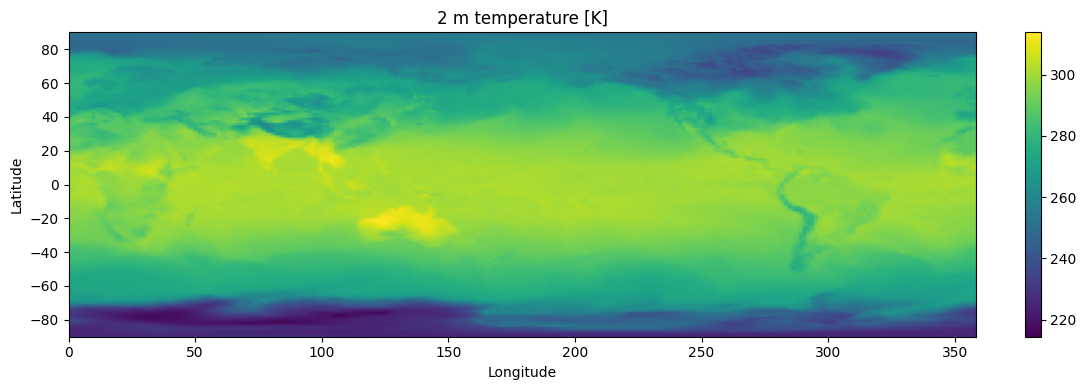

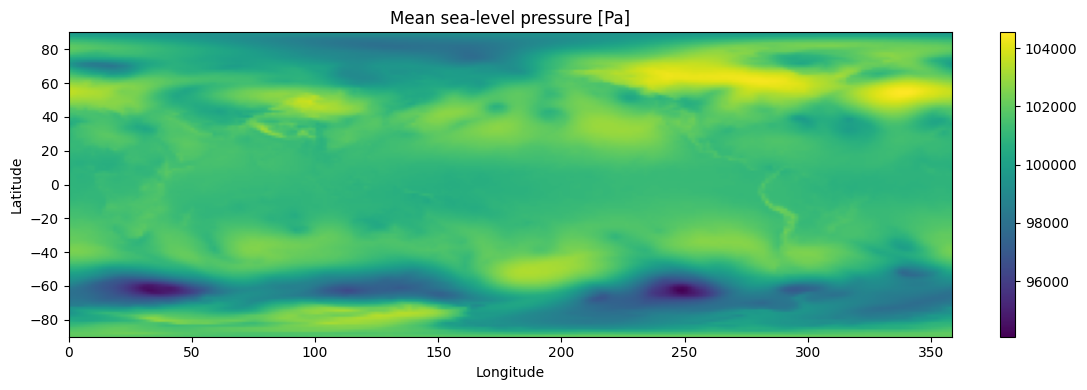

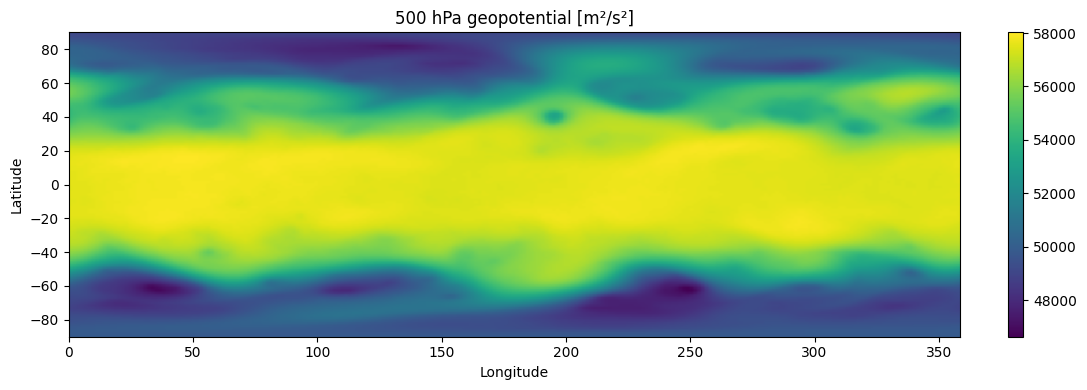

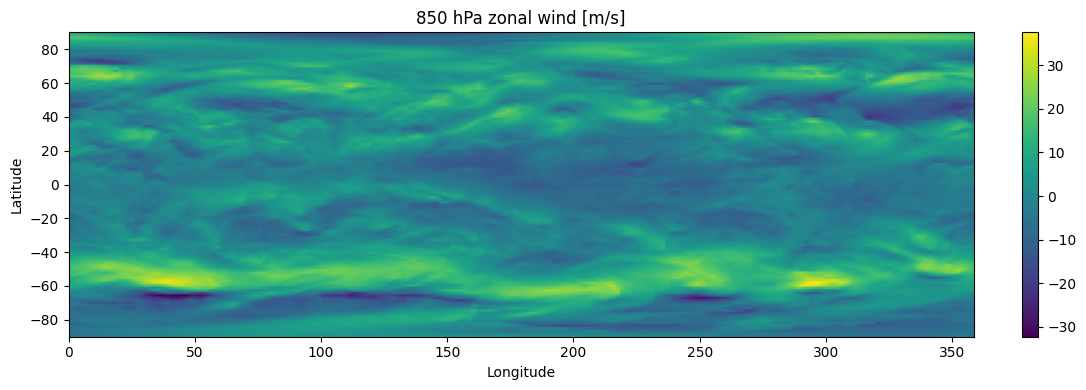

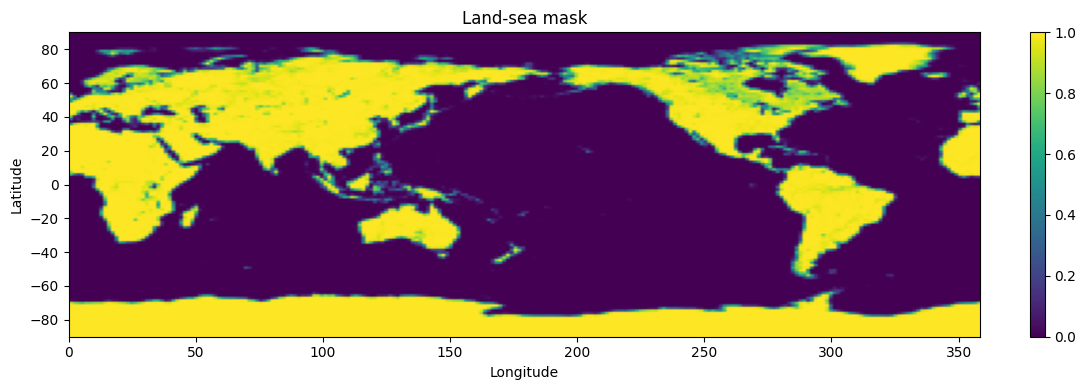

In [7]:
# @title Visualize selected validation fields
LEVEL_INDEX = {level: i for i, level in enumerate(LEVELS)}
sample = val_window
time_index = 1
extent = [sample["lon"][0], sample["lon"][-1], sample["lat"][-1], sample["lat"][0]]

fields = [
    ("2 m temperature [K]", sample["surf"]["2t"][time_index]),
    ("Mean sea-level pressure [Pa]", sample["surf"]["msl"][time_index]),
    ("500 hPa geopotential [m²/s²]", sample["atmos"]["z"][time_index, LEVEL_INDEX[500]]),
    ("850 hPa zonal wind [m/s]", sample["atmos"]["u"][time_index, LEVEL_INDEX[850]]),
    ("Land-sea mask", sample["static"]["lsm"]),
]

for title, field in fields:
    fig, ax = plt.subplots(figsize=(11, 4))
    im = ax.imshow(field, extent=extent, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(im, ax=ax, fraction=0.025)
    plt.tight_layout()
    safe = title.lower().replace(" ", "_").replace("/", "_")[:40]
    plt.savefig(produced(OUTPUT_ROOT / "figures" / f"state_{safe}.png"), dpi=140, bbox_inches="tight")
    plt.show()

# 8. Area weighting on a latitude–longitude grid

A regular latitude–longitude grid does not assign equal physical area to every cell.

Cells near the poles represent much less area than cells near the equator. The canonical global RMSE therefore uses:

\[
w(\phi)=\cos(\phi)
\]

with the latitude weights normalized to unit mean.

**Exercise:** What would happen if every 1.5° grid cell were weighted equally?

In [8]:
# @title Weighted and unweighted RMSE helpers
def lat_weights(lat):
    w = np.cos(np.deg2rad(np.asarray(lat, dtype=np.float64)))
    return w / w.mean()

def lat_weighted_rmse(pred, truth, lat):
    pred = np.asarray(pred, dtype=np.float64)
    truth = np.asarray(truth, dtype=np.float64)
    if pred.shape != truth.shape:
        raise ValueError(f"prediction {pred.shape} != truth {truth.shape}")
    w = lat_weights(lat)
    w = w[:, None] if pred.ndim == 2 else w[None, :, None]
    return float(np.sqrt(np.mean((pred - truth) ** 2 * w)))

def unweighted_rmse(pred, truth):
    pred = np.asarray(pred, dtype=np.float64)
    truth = np.asarray(truth, dtype=np.float64)
    return float(np.sqrt(np.mean((pred-truth)**2)))

# A persistence example on validation 2t at +6 h.
origin = 1
height = val_window["shape"][0] - (val_window["shape"][0] % PATCH_SIZE)
truth = val_window["surf"]["2t"][origin+1, :height]
persist = val_window["surf"]["2t"][origin, :height]
lat = val_window["lat"][:height]

print({
    "unweighted_rmse_K": unweighted_rmse(persist, truth),
    "latitude_weighted_rmse_K": lat_weighted_rmse(persist, truth, lat),
})

{'unweighted_rmse_K': 2.6920891185307285, 'latitude_weighted_rmse_K': 2.9911232091115294}


# 9. Build Aurora from the pinned checkpoint

Two model instances are conceptually important:

1. **frozen Aurora** — base checkpoint only;
2. **adaptable Aurora** — same base checkpoint with zero-initialized LoRA tensors.

Before LoRA training, those two models should represent the same pretrained forecasting function apart from numerical implementation effects.

In [9]:
# @title Model and Batch helpers
from aurora import AuroraSmallPretrained, Batch, Metadata, rollout

def build_aurora(use_lora):
    torch.manual_seed(SEED)
    model = AuroraSmallPretrained(use_lora=use_lora)
    # The source file was byte/digest verified above. The upstream loader uses
    # torch.load(..., weights_only=True) and adapts historical parameter names.
    model.load_checkpoint_local(str(checkpoint_path), strict=not use_lora)
    model = model.to(DEVICE).eval()
    for p in model.parameters():
        p.requires_grad_(False)

    if use_lora:
        names = [n for n, _ in model.named_parameters() if "lora" in n]
        n_params = sum(p.numel() for n, p in model.named_parameters() if "lora" in n)
        if len(names) != LORA_TENSORS_EXPECTED:
            raise ValueError(f"LoRA tensor count {len(names)} != expected {LORA_TENSORS_EXPECTED}")
        if n_params != LORA_PARAMETERS_EXPECTED:
            raise ValueError(f"LoRA parameter count {n_params} != expected {LORA_PARAMETERS_EXPECTED}")
    return model

def make_batch(window, origin):
    if origin < HISTORY_STEPS-1 or origin >= window["n_steps"]:
        raise ValueError(f"origin {origin} outside valid range")
    lo, hi = origin-HISTORY_STEPS+1, origin+1
    return Batch(
        surf_vars={
            k: torch.from_numpy(window["surf"][k][lo:hi][None])
            for k in SURF_VARS
        },
        static_vars={
            k: torch.from_numpy(window["static"][k])
            for k in STATIC_VARS
        },
        atmos_vars={
            k: torch.from_numpy(window["atmos"][k][lo:hi][None])
            for k in ATMOS_VARS
        },
        metadata=Metadata(
            lat=torch.tensor(window["lat"], dtype=torch.float32),
            lon=torch.tensor(window["lon"], dtype=torch.float32),
            time=(datetime.fromisoformat(window["times"][origin]),),
            atmos_levels=LEVELS,
        ),
    )

def forecast_from_origin(model, window, origin, steps):
    batch = make_batch(window, origin)
    with torch.inference_mode():
        preds = [p.to("cpu") for p in rollout(model, batch.to(DEVICE), steps=steps)]
    return preds

adapted_model = build_aurora(use_lora=True)

print({
    "base_parameters": PARAMETER_COUNT,
    "lora_parameters": LORA_PARAMETERS_EXPECTED,
    "lora_fraction_percent": 100 * LORA_PARAMETERS_EXPECTED / PARAMETER_COUNT,
    "device": DEVICE,
})

{'base_parameters': 112797584, 'lora_parameters': 540672, 'lora_fraction_percent': 0.47932941542435875, 'device': 'cuda'}


# 10. Persistence first

Persistence simply carries the latest analysis forward:

\[
\hat y_{t+h}=y_t
\]

At six hours it is often a surprisingly strong baseline. A learned weather model that cannot beat persistence on its deployment domain has not yet demonstrated useful forecast skill.

The notebook therefore calculates persistence **before** reporting Aurora.

### How the RMSE is aggregated

For each forecast origin, the notebook computes one latitude-weighted RMSE per variable and lead. For an atmospheric variable this RMSE pools all 13 pressure levels. It then averages these **per-origin RMSEs** over the origins. This is a mean of RMSEs, not one RMSE pooled over every origin's errors: origin RMSEs of 1 and 3 give 2.0, whereas pooling their squared errors would give about 2.24. Both conventions are coherent, and this notebook uses the first. The RMSE ratio divides the model's value by persistence's. The nine-variable mean ratio leaves out any variable whose persistence RMSE is 0, because its ratio is undefined. z500 is reported separately as a diagnostic.

Before scoring, the evaluator checks every forecast. It needs exactly one forecast per origin, the expected variables and shapes, finite values, and a valid time equal to the origin plus 6 h × lead. A malformed or non-finite forecast is refused instead of being scored as a poor one.

In [10]:
# @title Common forecast evaluator
HEADLINE_LEVEL = 500
REPORTED = (*SURF_VARS, *ATMOS_VARS, "z500")
METRIC_CONVENTION = (
    "latitude-weighted RMSE computed separately for each forecast origin, then averaged over origins "
    "(a mean of per-origin RMSEs, not one RMSE pooled over origins); an atmospheric variable's RMSE pools its "
    "13 pressure levels within each origin; skill = model RMSE / persistence RMSE, undefined (NaN) when the "
    "persistence RMSE is 0 and then left out of the nine-variable mean; z500 is a separate diagnostic outside that mean"
)

def check_forecast_fields(pred, window, height, where):
    """Refuse a forecast that is not exactly the expected finite fields on the evaluation grid."""
    if not isinstance(pred, dict) or set(pred) != {"surf", "atmos"}:
        raise ValueError(f"{where}: a forecast must hold exactly 'surf' and 'atmos' fields")
    width = window["shape"][1]
    for group, names, shape in (
        ("surf", SURF_VARS, (height, width)),
        ("atmos", ATMOS_VARS, (len(LEVELS), height, width)),
    ):
        fields = pred[group]
        if set(fields) != set(names):
            raise ValueError(f"{where}: {group} variables {sorted(fields)} != expected {sorted(names)}")
        for name in names:
            arr = np.asarray(fields[name])
            if arr.shape != shape:
                raise ValueError(f"{where}: {group}/{name} has shape {arr.shape}, expected {shape}")
            if not np.isfinite(arr).all():
                raise ValueError(f"{where}: {group}/{name} contains non-finite values; refusing to score an invalid forecast")

def _as_datetime(value):
    if isinstance(value, datetime):
        return value.replace(tzinfo=None)
    return datetime.fromisoformat(str(value)[:19])

def forecast_arrays(preds, window, origin):
    """NumPy fields for each rolled-out lead, after checking that lead k is valid at origin + 6 h x k."""
    start = datetime.fromisoformat(window["times"][origin])
    out = []
    for k, p in enumerate(preds, start=1):
        valid = _as_datetime(p.metadata.time[0])
        expected = start + timedelta(hours=TIMESTEP_HOURS * k)
        if valid != expected:
            raise ValueError(f"origin {origin}: lead {k} forecast is valid at {valid}, expected {expected}")
        out.append({
            "surf": {name: p.surf_vars[name][0, 0].numpy() for name in SURF_VARS},
            "atmos": {name: p.atmos_vars[name][0, 0].numpy() for name in ATMOS_VARS},
        })
    return out

def forecast_metrics(window, origins, predictions):
    height = window["shape"][0] - (window["shape"][0] % PATCH_SIZE)
    lat = window["lat"][:height]
    level_500 = LEVELS.index(500)
    origins = [int(o) for o in origins]
    if not origins:
        raise ValueError("no forecast origins to score")
    if len(set(origins)) != len(origins):
        raise ValueError(f"duplicate forecast origins {origins}")
    if len(predictions) != len(origins):
        raise ValueError(f"{len(predictions)} forecast sets for {len(origins)} origins; every origin needs exactly one")
    n_leads = len(predictions[0])
    if n_leads == 0:
        raise ValueError("the forecasts contain no lead times")
    for origin, preds in zip(origins, predictions, strict=True):
        if len(preds) != n_leads:
            raise ValueError(f"origin {origin}: {len(preds)} leads, expected {n_leads}")
        if origin < HISTORY_STEPS - 1 or origin + n_leads >= window["n_steps"]:
            raise ValueError(
                f"origin {origin} with {n_leads} leads needs analyses up to index {origin + n_leads}; "
                f"the window has {window['n_steps']}"
            )
        for k, pred in enumerate(preds):
            check_forecast_fields(pred, window, height, f"origin {origin}, +{(k + 1) * TIMESTEP_HOURS} h")
    result = {name: {} for name in REPORTED}

    for k in range(n_leads):
        lead = f"{(k+1)*6}h"
        model_errors = {name: [] for name in REPORTED}
        persistence_errors = {name: [] for name in REPORTED}

        for origin, preds in zip(origins, predictions, strict=True):
            target_index = origin + k + 1
            for name in SURF_VARS:
                truth = window["surf"][name][target_index, :height]
                model_errors[name].append(
                    lat_weighted_rmse(preds[k]["surf"][name], truth, lat)
                )
                persistence_errors[name].append(
                    lat_weighted_rmse(window["surf"][name][origin, :height], truth, lat)
                )
            for name in ATMOS_VARS:
                truth = window["atmos"][name][target_index, :, :height]
                model_errors[name].append(
                    lat_weighted_rmse(preds[k]["atmos"][name], truth, lat)
                )
                persistence_errors[name].append(
                    lat_weighted_rmse(window["atmos"][name][origin, :, :height], truth, lat)
                )

            truth = window["atmos"]["z"][target_index, level_500, :height]
            model_errors["z500"].append(
                lat_weighted_rmse(preds[k]["atmos"]["z"][level_500], truth, lat)
            )
            persistence_errors["z500"].append(
                lat_weighted_rmse(window["atmos"]["z"][origin, level_500, :height], truth, lat)
            )

        for name in REPORTED:
            model_rmse = float(np.mean(model_errors[name]))
            persistence_rmse = float(np.mean(persistence_errors[name]))
            result[name][lead] = {
                "model": model_rmse,
                "persistence": persistence_rmse,
                "skill": model_rmse / persistence_rmse if persistence_rmse > 0 else np.nan,
            }

    leads = [f"{(k+1)*6}h" for k in range(n_leads)]
    summary = {}
    for lead in leads:
        ratios = [result[name][lead]["skill"] for name in REPORTED if name != "z500"]
        defined = [r for r in ratios if np.isfinite(r)]
        summary[lead] = {
            "mean_skill": float(np.mean(defined)) if defined else float("nan"),
            "variables_beating_persistence": int(sum(r < 1 for r in defined)),
            "variables_with_defined_ratio": len(defined),
        }
    return {
        "n_origins": len(origins),
        "origins": origins,
        "origin_times": [window["times"][o] for o in origins],
        "leads": leads,
        "variables": result,
        "summary": summary,
        "metric": METRIC_CONVENTION,
    }

def evaluate_model(model, window, max_steps=4, origins=None):
    chosen = eval_origins(window, max_steps) if origins is None else [int(o) for o in origins]
    if not chosen:
        raise ValueError(
            f"window has {window['n_steps']} analyses; {HISTORY_STEPS + max_steps} are needed for {max_steps} lead steps"
        )
    predictions = []
    for origin in chosen:
        preds = forecast_from_origin(model, window, origin, max_steps)
        if len(preds) != max_steps:
            raise ValueError(f"origin {origin}: rollout returned {len(preds)} leads, expected {max_steps}")
        predictions.append(forecast_arrays(preds, window, origin))
    return forecast_metrics(window, chosen, predictions)

def persistence_only(window, max_steps=4, origins=None):
    height = window["shape"][0] - (window["shape"][0] % PATCH_SIZE)
    chosen = eval_origins(window, max_steps) if origins is None else [int(o) for o in origins]
    if not chosen:
        raise ValueError(
            f"window has {window['n_steps']} analyses; {HISTORY_STEPS + max_steps} are needed for {max_steps} lead steps"
        )
    predictions = [
        [
            {
                "surf": {k: window["surf"][k][origin, :height] for k in SURF_VARS},
                "atmos": {k: window["atmos"][k][origin, :, :height] for k in ATMOS_VARS},
            }
            for _ in range(max_steps)
        ]
        for origin in chosen
    ]
    scored = forecast_metrics(window, chosen, predictions)
    return {
        "leads": scored["leads"],
        "origins": scored["origins"],
        "variables": {
            name: {
                lead: {"persistence": values["persistence"]}
                for lead, values in lead_values.items()
            }
            for name, lead_values in scored["variables"].items()
        },
        "baseline": "persistence",
        "metric": METRIC_CONVENTION,
    }

val_persistence = persistence_only(val_window, MAX_LEAD_STEPS)
produced(OUTPUT_ROOT / "baseline" / "validation_persistence.json").write_text(
    json.dumps(val_persistence, indent=2), encoding="utf-8"
)

print("Validation persistence RMSE:")
for name in ("2t", "msl", "z500"):
    print(name, {
        lead: round(values["persistence"], 4)
        for lead, values in val_persistence["variables"][name].items()
    })

Validation persistence RMSE:
2t {'6h': 2.7004, '12h': 3.6936, '18h': 3.2141, '24h': 1.9941}
msl {'6h': 261.1796, '12h': 387.503, '18h': 535.6019, '24h': 614.2006}
z500 {'6h': 236.7974, '12h': 374.0863, '18h': 525.4159, '24h': 628.6764}


# 11. Frozen Aurora on validation — diagnose the domain shift

The adaptable model currently has zero-initialized LoRA tensors, so it is still the frozen pretrained forecast.

At the tutorial's 1.5° grid, **losing to persistence is an expected and scientifically useful result**. It shows that correct variable names and units alone do not guarantee transfer.

The grid change is a well-motivated explanation, because each grid cell and each 4×4 token now covers a much larger physical area than during pretraining. It is **not isolated** by this comparison, however. The notebook does not run this checkpoint at its native 0.25° resolution under otherwise matched conditions, and it uses the small debugging checkpoint. Losing to persistence on one coarse sample therefore supports *resolution shift as a plausible contributor*, not a proven sole cause.

,lead,mean_rmse_ratio_vs_persistence,variables_beating_persistence,of
0,6h,1.572999,1,9
1,12h,1.355079,1,9
2,18h,1.245819,0,9
3,24h,1.285941,1,9


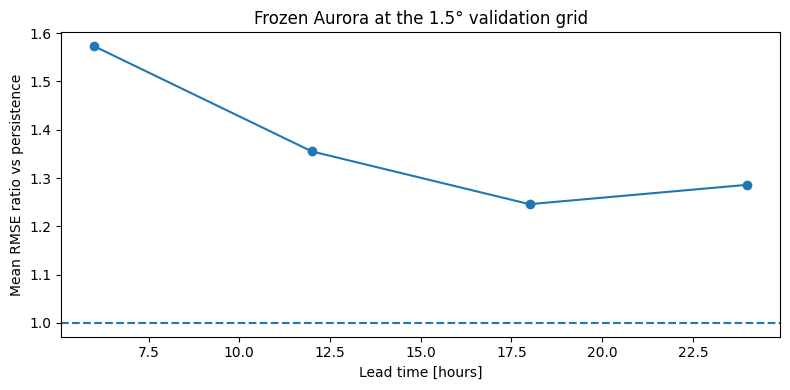

In [11]:
# @title Frozen validation forecast
import time

started = time.perf_counter()
frozen_validation = evaluate_model(adapted_model, val_window, MAX_LEAD_STEPS)
frozen_validation_seconds = time.perf_counter() - started

produced(OUTPUT_ROOT / "frozen_model" / "validation_metrics.json").write_text(
    json.dumps(frozen_validation, indent=2), encoding="utf-8"
)

validation_summary = pd.DataFrame([
    {
        "lead": lead,
        "mean_rmse_ratio_vs_persistence": frozen_validation["summary"][lead]["mean_skill"],
        "variables_beating_persistence": frozen_validation["summary"][lead]["variables_beating_persistence"],
        "of": 9,
    }
    for lead in frozen_validation["leads"]
])
display(validation_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    [int(x[:-1]) for x in validation_summary["lead"]],
    validation_summary["mean_rmse_ratio_vs_persistence"],
    marker="o",
)
ax.axhline(1.0, linestyle="--")
ax.set_xlabel("Lead time [hours]")
ax.set_ylabel("Mean RMSE ratio vs persistence")
ax.set_title(f"Frozen Aurora at the {val_window['resolution_degrees']:g}° validation grid")
plt.tight_layout()
plt.savefig(produced(OUTPUT_ROOT / "figures" / "validation_frozen_skill.png"), dpi=150, bbox_inches="tight")
plt.show()

## Interpretation checkpoint

Aurora was trained at 0.25°. At 1.5°:

- horizontal gradients are smoother;
- extremes are reduced by regridding;
- orography is coarser;
- the spatial scale represented by each token changes dramatically.

**Exercise:** Why should a pretrained neural forecaster be expected to notice that change even if the variable names, units, and global coverage remain correct?

# 12. LoRA adaptation

Aurora's attention layers expose rank-8 LoRA parameters.

Canonical adaptation:

- 80 LoRA tensors;
- 540,672 trainable parameters;
- approximately 0.48% of the 113M base model;
- train on January + July 2019;
- validate on April 2020;
- six epochs;
- AdamW;
- one-step (+6 h) training loss;
- lowest validation loss selects the final state.

Epoch 0 — the frozen model — remains eligible. If adaptation does not improve the validation objective, the notebook keeps the frozen policy.

In [12]:
# @title LoRA adaptation helpers
import copy

def trainable_names(model, mode):
    if mode not in {"lora", "lora+heads"}:
        raise ValueError(mode)
    prefixes = (
        "decoder.surf_heads.",
        "decoder.atmos_heads.",
        "encoder.surf_token_embeds.",
        "encoder.atmos_token_embeds.",
    )
    names = []
    for name, _ in model.named_parameters():
        if "lora" in name or (mode == "lora+heads" and name.startswith(prefixes)):
            names.append(name)
    return names

def target_fields(window, origin):
    height = window["shape"][0] - (window["shape"][0] % PATCH_SIZE)
    return {
        **{
            k: torch.from_numpy(window["surf"][k][origin+1, :height]).to(DEVICE)
            for k in SURF_VARS
        },
        **{
            k: torch.from_numpy(window["atmos"][k][origin+1, :, :height]).to(DEVICE)
            for k in ATMOS_VARS
        },
    }

def scaled_loss(pred, target, scales):
    total = 0.0
    for k in SURF_VARS:
        total = total + torch.mean(((pred.surf_vars[k][0,0] - target[k]) / scales[k])**2)
    for k in ATMOS_VARS:
        total = total + torch.mean(((pred.atmos_vars[k][0,0] - target[k]) / scales[k])**2)
    return total / (len(SURF_VARS) + len(ATMOS_VARS))

def one_step_validation_loss(model, window, scales):
    model.eval()
    values = []
    with torch.inference_mode():
        for origin in range(HISTORY_STEPS-1, window["n_steps"]-1):
            pred = model(make_batch(window, origin).to(DEVICE))
            values.append(float(scaled_loss(pred, target_fields(window, origin), scales)))
    return float(np.mean(values))

def adapt_model(model, train_windows, val_window, epochs, lr, mode, seed):
    torch.manual_seed(seed)
    names = trainable_names(model, mode)
    wanted = set(names)

    for name, param in model.named_parameters():
        param.requires_grad_(name in wanted)

    params = [p for p in model.parameters() if p.requires_grad]
    n_trainable = sum(p.numel() for p in params)

    if mode == "lora":
        if len(names) != LORA_TENSORS_EXPECTED:
            raise ValueError(f"LoRA tensor count {len(names)} != {LORA_TENSORS_EXPECTED}")
        if n_trainable != LORA_PARAMETERS_EXPECTED:
            raise ValueError(f"LoRA params {n_trainable} != {LORA_PARAMETERS_EXPECTED}")

    optimizer = torch.optim.AdamW(params, lr=lr)
    scales = {
        k: torch.tensor(v, dtype=torch.float32, device=DEVICE)
        for k, v in LOSS_SCALES.items()
    }

    samples = [
        (window, origin)
        for window in train_windows
        for origin in range(HISTORY_STEPS-1, window["n_steps"]-1)
    ]
    generator = torch.Generator().manual_seed(seed)

    initial = {k: v.detach().clone() for k, v in model.state_dict().items() if k in wanted}
    best_state = copy.deepcopy(initial)
    best_epoch = 0
    best_val = one_step_validation_loss(model, val_window, scales)
    history = [{
        "epoch": 0,
        "train_loss": None,
        "val_loss": best_val,
        "note": "frozen model / zero LoRA",
    }]

    started = time.perf_counter()
    try:
        for epoch in range(1, epochs+1):
            model.train()
            order = torch.randperm(len(samples), generator=generator).tolist()
            losses = []
            for idx in order:
                window, origin = samples[idx]
                pred = model(make_batch(window, origin).to(DEVICE))
                loss = scaled_loss(pred, target_fields(window, origin), scales)
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(params, 1.0)
                optimizer.step()
                losses.append(float(loss.detach()))

            val_loss = one_step_validation_loss(model, val_window, scales)
            entry = {
                "epoch": epoch,
                "train_loss": float(np.mean(losses)),
                "val_loss": val_loss,
            }
            history.append(entry)
            print(entry)

            if val_loss < best_val:
                best_val = val_loss
                best_epoch = epoch
                best_state = {
                    k: v.detach().clone()
                    for k, v in model.state_dict().items()
                    if k in wanted
                }
    except BaseException:
        merged = dict(model.state_dict())
        merged.update(initial)
        model.load_state_dict(merged, strict=True)
        for p in model.parameters():
            p.requires_grad_(False)
        model.eval()
        raise

    merged = dict(model.state_dict())
    merged.update(best_state)
    model.load_state_dict(merged, strict=True)
    for p in model.parameters():
        p.requires_grad_(False)
    model.eval()

    return {
        "trainable": mode,
        "trainable_names": names,
        "n_trainable": n_trainable,
        "n_total": sum(p.numel() for p in model.parameters()),
        "epochs": epochs,
        "best_epoch": best_epoch,
        "learning_rate": lr,
        "seed": seed,
        "loss_scales": LOSS_SCALES,
        "n_train_samples": len(samples),
        "history": history,
        "seconds": time.perf_counter() - started,
    }

adaptation = adapt_model(
    adapted_model,
    train_windows,
    val_window,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    mode=TRAINABLE,
    seed=SEED,
)

produced(OUTPUT_ROOT / "adaptation" / "training_history.json").write_text(
    json.dumps(adaptation, indent=2), encoding="utf-8"
)

display(pd.DataFrame(adaptation["history"]))
print({
    "best_epoch": adaptation["best_epoch"],
    "trainable_parameters": adaptation["n_trainable"],
    "percent_of_base": 100 * adaptation["n_trainable"] / PARAMETER_COUNT,
    "training_seconds": adaptation["seconds"],
})

{'epoch': 1, 'train_loss': 0.14134077541530132, 'val_loss': 0.100042009105285}
{'epoch': 2, 'train_loss': 0.08408458344638348, 'val_loss': 0.07940302044153214}
{'epoch': 3, 'train_loss': 0.068623723462224, 'val_loss': 0.06996069848537445}
{'epoch': 4, 'train_loss': 0.05939265185346206, 'val_loss': 0.062339840456843376}
{'epoch': 5, 'train_loss': 0.05384235984335343, 'val_loss': 0.0568055926511685}
{'epoch': 6, 'train_loss': 0.049367986619472504, 'val_loss': 0.05363894316057364}


,epoch,train_loss,val_loss,note
0,0,NaN,0.184840,frozen model / zero LoRA
1,1,0.141341,0.100042,NaN
2,2,0.084085,0.079403,NaN
3,3,0.068624,0.069961,NaN
4,4,0.059393,0.062340,NaN
5,5,0.053842,0.056806,NaN
6,6,0.049368,0.053639,NaN


{'best_epoch': 6, 'trainable_parameters': 540672, 'percent_of_base': 0.47932941542435875, 'training_seconds': 37.183350960999974}


# 13. Validate the selected adapted model

The training objective is one-step scaled MSE. The scientifically relevant question, however, is how the selected model behaves during an autoregressive rollout.

The next cell compares the selected adapted model with its own persistence baseline over 6–24 hours **on validation only**.

In [13]:
# @title Adapted validation rollout
adapted_validation = evaluate_model(adapted_model, val_window, MAX_LEAD_STEPS)

produced(OUTPUT_ROOT / "adaptation" / "validation_metrics.json").write_text(
    json.dumps(adapted_validation, indent=2), encoding="utf-8"
)

val_compare = pd.DataFrame([
    {
        "lead": lead,
        "frozen_mean_ratio": frozen_validation["summary"][lead]["mean_skill"],
        "adapted_mean_ratio": adapted_validation["summary"][lead]["mean_skill"],
        "frozen_vars_beating_persistence": frozen_validation["summary"][lead]["variables_beating_persistence"],
        "adapted_vars_beating_persistence": adapted_validation["summary"][lead]["variables_beating_persistence"],
    }
    for lead in frozen_validation["leads"]
])
display(val_compare)

,lead,frozen_mean_ratio,adapted_mean_ratio,frozen_vars_beating_persistence,adapted_vars_beating_persistence
0,6h,1.572999,0.931588,1,6
1,12h,1.355079,0.894133,1,8
2,18h,1.245819,0.903341,0,7
3,24h,1.285941,0.976054,1,6


# 14. Freeze the experiment before the independent test

No test metric has been used for:

- choosing LoRA versus `lora+heads`;
- choosing the epoch;
- changing learning rate;
- changing lead times;
- changing the persistence definition; or
- changing the metric.

The next record freezes those choices before final test evaluation. It also binds the test to them. It records a digest of the **selected adapter tensors**, the content digest of the test window, the adaptation scope, and the exact test leads and origins, and it is itself digested.

Section 15 recomputes those identities from the live notebook state before any test forecast runs, and **refuses** to evaluate if anything has changed. It then takes the leads and origins from the record, not from the controls. Changing a setting after freezing therefore requires a new freeze. A new freeze never overwrites a different earlier one: that record is kept under `frozen/superseded/`.

> **What to notice.** Compare the model result with the stated baseline/reference first. Then inspect the secondary metric or diagnostic that explains *how* the result was achieved; do not infer a universal model ranking from one sample and configuration.

In [14]:
# @title Freeze experiment
def tensor_state_digest(tensors):
    """SHA-256 over sorted tensor names, shapes and float32 values: the identity of a selected adapter state."""
    h = hashlib.sha256()
    for name in sorted(tensors):
        value = tensors[name]
        if hasattr(value, "detach"):
            value = value.detach().to("cpu").float().numpy()
        arr = np.ascontiguousarray(np.asarray(value, dtype=np.float32))
        h.update(name.encode()); h.update(json.dumps(list(arr.shape)).encode()); h.update(arr.tobytes())
    return h.hexdigest()

def selected_adapter_state(model, names):
    wanted = set(names)
    return {k: v for k, v in model.state_dict().items() if k in wanted}

def experiment_sha256(record):
    """Digest of a frozen record's JSON content, excluding the digest field itself."""
    body = {k: v for k, v in record.items() if k != "experiment_sha256"}
    return hashlib.sha256(json.dumps(body, sort_keys=True, default=str).encode("utf-8")).hexdigest()

def freeze_mismatches(record, *, checkpoint_sha256, trainable, adapter_state_sha256, test_content_sha256, lead_steps):
    """Every way the live state differs from a frozen experiment record; an empty list means the same experiment."""
    problems = []
    if record.get("experiment_sha256") != experiment_sha256(record):
        problems.append("the frozen record was edited after it was written")
    if record["model"]["checkpoint_sha256"] != checkpoint_sha256:
        problems.append("base checkpoint identity")
    if record["adaptation"]["trainable"] != trainable:
        problems.append(f"adaptation scope (frozen {record['adaptation']['trainable']!r}, live {trainable!r})")
    if record["selected_adapter"]["state_sha256"] != adapter_state_sha256:
        problems.append("selected adapter tensors")
    request = record["test_request"]
    if request["window_content_sha256"] != test_content_sha256:
        problems.append("test window data")
    if request["lead_steps"] != lead_steps:
        problems.append(f"evaluation lead steps (frozen {request['lead_steps']}, live {lead_steps})")
    return problems

frozen_experiment = {
    "notebook_spec": "2.1",
    "profile": "E2E",
    "mode": "WORKSHOP",
    "model": {
        "id": MODEL_ID,
        "revision": MODEL_REVISION,
        "checkpoint_name": CHECKPOINT_NAME,
        "checkpoint_bytes": CHECKPOINT_BYTES,
        "checkpoint_sha256": CHECKPOINT_SHA256,
        "checkpoint_loading": "upstream weights_only checkpoint loader after local digest verification",
        "small_checkpoint_boundary": True,
    },
    "dataset": dataset_manifest,
    "state_contract": {
        "surface_variables": list(SURF_VARS),
        "atmospheric_variables": list(ATMOS_VARS),
        "static_variables": list(STATIC_VARS),
        "pressure_levels_hpa": list(LEVELS),
        "history_steps": HISTORY_STEPS,
        "timestep_hours": TIMESTEP_HOURS,
        "tutorial_resolution_degrees": val_window["resolution_degrees"],
        "training_resolution_degrees": 0.25,
    },
    "adaptation": {
        k: v for k, v in adaptation.items()
        if k not in {"trainable_names"}
    },
    "trainable_tensor_names": adaptation["trainable_names"],
    "evaluation": {
        "metric": "latitude-weighted RMSE with cosine-latitude weights normalized to unit mean",
        "persistence": "latest analysis carried unchanged to every lead",
        "skill_semantics": "model RMSE / persistence RMSE; below 1 beats persistence",
        "lead_hours": [6 * i for i in range(1, MAX_LEAD_STEPS+1)],
        "z500_is_diagnostic_not_tenth_summary_variable": True,
    },
    "validation": {
        "frozen": frozen_validation,
        "adapted": adapted_validation,
    },
    "base_conversion": base_receipt,
    "selected_adapter": {
        "state_sha256": tensor_state_digest(selected_adapter_state(adapted_model, adaptation["trainable_names"])),
        "n_tensors": len(adaptation["trainable_names"]),
        "best_epoch": adaptation["best_epoch"],
    },
    "validation_window_content_sha256": window_content_digest(val_window),
    "test_request": {
        "window_role": "test",
        "window_name": test_window["name"],
        "window_content_sha256": window_content_digest(test_window),
        "lead_steps": MAX_LEAD_STEPS,
        "origins": eval_origins(test_window, MAX_LEAD_STEPS),
        "origin_times": [test_window["times"][o] for o in eval_origins(test_window, MAX_LEAD_STEPS)],
    },
}
# Round-trip through JSON first so the digest describes exactly the bytes written to disk.
frozen_record = json.loads(json.dumps(frozen_experiment, default=str))
frozen_record["experiment_sha256"] = experiment_sha256(frozen_record)

freeze_path = OUTPUT_ROOT / "frozen" / "frozen_experiment.json"
if freeze_path.exists():
    previous = json.loads(freeze_path.read_text(encoding="utf-8"))
    if previous.get("experiment_sha256") != frozen_record["experiment_sha256"]:
        # A completed freeze is never silently replaced: a changed experiment is a new experiment.
        kept = OUTPUT_ROOT / "frozen" / "superseded" / f"frozen_experiment_{str(previous.get('experiment_sha256') or 'unhashed')[:12]}.json"
        kept.parent.mkdir(parents=True, exist_ok=True)
        freeze_path.replace(kept)
        print("A different experiment had been frozen here; it is kept at", kept)
produced(freeze_path).write_text(json.dumps(frozen_record, indent=2), encoding="utf-8")
print("Experiment frozen:", freeze_path, "experiment_sha256", frozen_record["experiment_sha256"][:12])

Experiment frozen: outputs/frozen/frozen_experiment.json experiment_sha256 eefe721001a2


# 15. Independent test (October 2021 in the built-in sample)

The test first verifies the frozen record from section 14 against the live model, data and settings.

The test now compares three forecast systems:

1. persistence;
2. a **fresh** zero-LoRA Aurora model;
3. the validation-selected adapted model.

The frozen model is reconstructed only after the experiment is frozen, so its test metrics cannot influence the adaptation choices.

In [15]:
# @title Independent test comparison
# Bind the test to the frozen record: the live model, data and settings must be the ones that were frozen.
frozen_record = json.loads(freeze_path.read_text(encoding="utf-8"))
freeze_problems = freeze_mismatches(
    frozen_record,
    checkpoint_sha256=CHECKPOINT_SHA256,
    trainable=TRAINABLE,
    adapter_state_sha256=tensor_state_digest(selected_adapter_state(adapted_model, adaptation["trainable_names"])),
    test_content_sha256=window_content_digest(test_window),
    lead_steps=MAX_LEAD_STEPS,
)
if freeze_problems:
    raise RuntimeError(
        "The live notebook state no longer matches the frozen experiment: " + "; ".join(freeze_problems)
        + ". Re-run from '14. Freeze the experiment' to record a new experiment "
        "(an earlier record is kept under frozen/superseded/)."
    )
# The test request comes from the verified record, not from the (mutable) controls.
TEST_LEAD_STEPS = frozen_record["test_request"]["lead_steps"]
TEST_ORIGINS = frozen_record["test_request"]["origins"]

test_persistence = persistence_only(test_window, TEST_LEAD_STEPS, origins=TEST_ORIGINS)

fresh_frozen_model = build_aurora(use_lora=True)

started = time.perf_counter()
frozen_test = evaluate_model(fresh_frozen_model, test_window, TEST_LEAD_STEPS, origins=TEST_ORIGINS)
frozen_test_seconds = time.perf_counter() - started

started = time.perf_counter()
adapted_test = evaluate_model(adapted_model, test_window, TEST_LEAD_STEPS, origins=TEST_ORIGINS)
adapted_test_seconds = time.perf_counter() - started

comparison = pd.DataFrame([
    {
        "lead_hours": int(lead[:-1]),
        "frozen_mean_rmse_ratio": frozen_test["summary"][lead]["mean_skill"],
        "adapted_mean_rmse_ratio": adapted_test["summary"][lead]["mean_skill"],
        "frozen_vars_beating_persistence": frozen_test["summary"][lead]["variables_beating_persistence"],
        "adapted_vars_beating_persistence": adapted_test["summary"][lead]["variables_beating_persistence"],
        "variables": 9,
    }
    for lead in frozen_test["leads"]
])
display(comparison)

comparison.to_csv(produced(OUTPUT_ROOT / "test" / "comparison.csv"), index=False)
produced(OUTPUT_ROOT / "test" / "frozen_metrics.json").write_text(
    json.dumps(frozen_test, indent=2), encoding="utf-8"
)
produced(OUTPUT_ROOT / "test" / "adapted_metrics.json").write_text(
    json.dumps(adapted_test, indent=2), encoding="utf-8"
)

variable_rows = []
for name in REPORTED:
    for lead in frozen_test["leads"]:
        variable_rows.append({
            "variable": name,
            "lead": lead,
            "persistence_rmse": frozen_test["variables"][name][lead]["persistence"],
            "frozen_rmse": frozen_test["variables"][name][lead]["model"],
            "frozen_ratio": frozen_test["variables"][name][lead]["skill"],
            "adapted_rmse": adapted_test["variables"][name][lead]["model"],
            "adapted_ratio": adapted_test["variables"][name][lead]["skill"],
            "unit": UNITS.get("z" if name == "z500" else name, ""),
        })
variable_table = pd.DataFrame(variable_rows)
display(variable_table[variable_table["variable"].isin(["2t", "msl", "z500", "u"])])
variable_table.to_csv(produced(OUTPUT_ROOT / "test" / "variable_metrics.csv"), index=False)

,lead_hours,frozen_mean_rmse_ratio,adapted_mean_rmse_ratio,frozen_vars_beating_persistence,adapted_vars_beating_persistence,variables
0,6,1.568051,0.913704,1,6,9
1,12,1.327926,0.867310,1,8,9
2,18,1.237117,0.887508,1,7,9
3,24,1.293737,0.996769,2,6,9


,variable,lead,persistence_rmse,frozen_rmse,frozen_ratio,adapted_rmse,adapted_ratio,unit
0,2t,6h,2.665918,2.459192,0.922456,1.771304,0.664426,K
1,2t,12h,3.628601,3.242790,0.893675,2.699950,0.744075,K
2,2t,18h,3.106182,3.530526,1.136613,2.671471,0.860050,K
3,2t,24h,1.804413,3.706666,2.054222,2.867111,1.588944,K
12,msl,6h,269.141103,414.644570,1.540622,239.311732,0.889168,Pa
13,msl,12h,392.725093,584.403593,1.488073,359.841754,0.916269,Pa
14,msl,18h,524.715721,699.498966,1.333101,493.939733,0.941347,Pa
15,msl,24h,584.746807,771.775758,1.319846,566.236364,0.968345,Pa
20,u,6h,3.639071,7.494901,2.059564,3.347901,0.919988,m/s
21,u,12h,5.525572,8.692264,1.573097,4.722488,0.854660,m/s


## Reference expectation, not a canned answer

A previous clean DIMER T4 run at the same 1.5° tutorial setup observed frozen → adapted mean RMSE ratios of approximately:

- 6 h: 1.568 → 0.904
- 12 h: 1.328 → 0.849
- 18 h: 1.237 → 0.867
- 24 h: 1.294 → 0.969

Those values are **not injected into this notebook's results**. The table above is recomputed from this execution.

# 16. Lead-time error growth

Autoregressive forecasts feed predictions back into the next model step, so errors can accumulate with lead.

The following curves keep physical RMSE and relative-to-persistence behavior visible together.

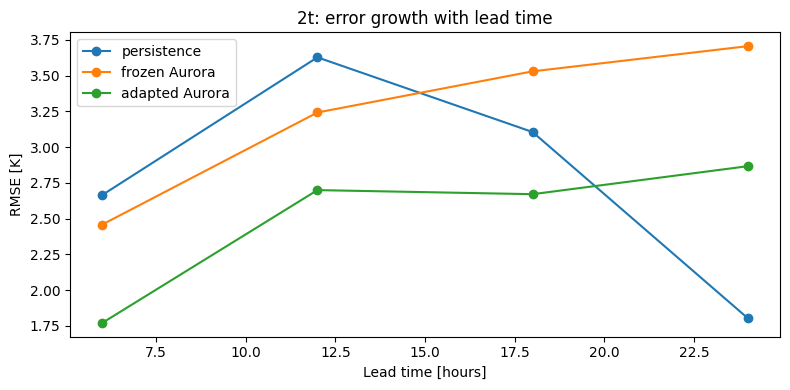

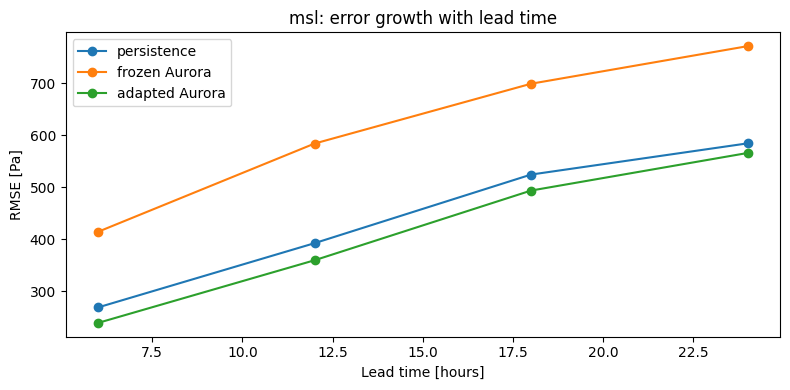

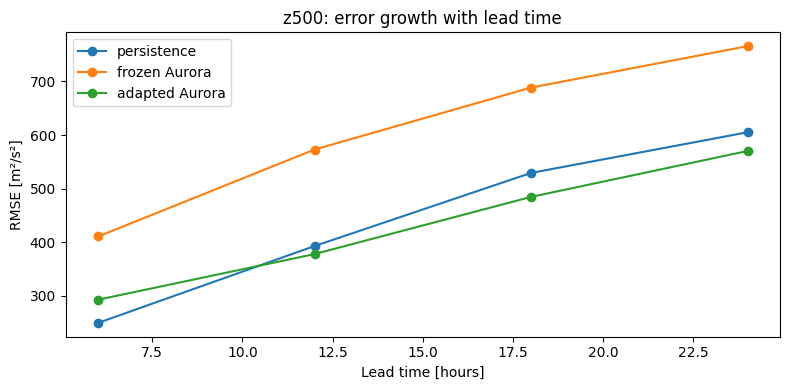

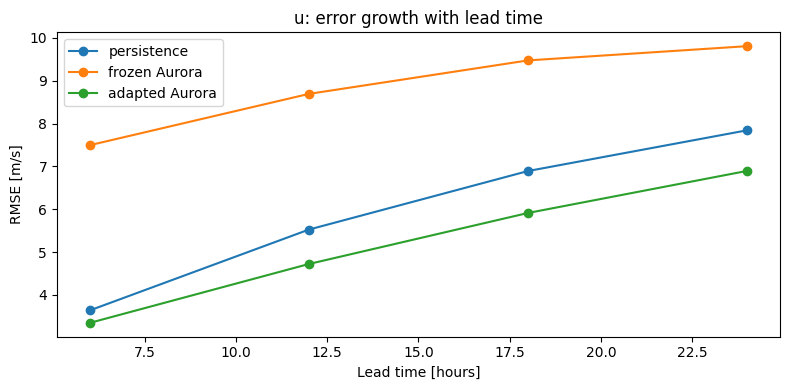

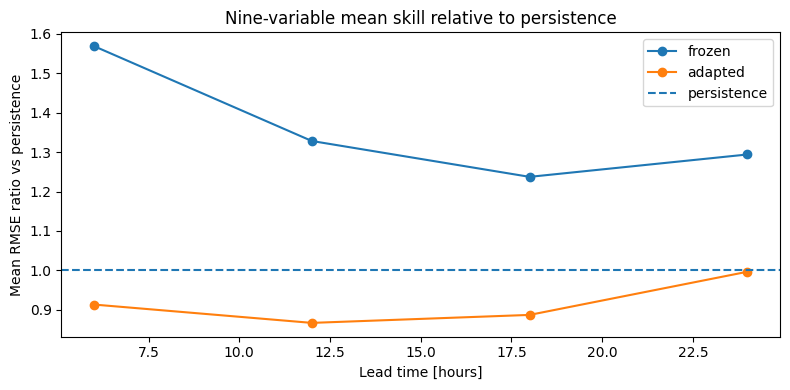

In [16]:
# @title Lead-time curves for headline variables
for variable in ("2t", "msl", "z500", "u"):
    block = variable_table[variable_table["variable"] == variable].copy()
    leads = block["lead"].str.replace("h", "", regex=False).astype(int)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(leads, block["persistence_rmse"], marker="o", label="persistence")
    ax.plot(leads, block["frozen_rmse"], marker="o", label="frozen Aurora")
    ax.plot(leads, block["adapted_rmse"], marker="o", label="adapted Aurora")
    ax.set_xlabel("Lead time [hours]")
    ax.set_ylabel(f"RMSE [{block['unit'].iloc[0]}]")
    ax.set_title(f"{variable}: error growth with lead time")
    ax.legend()
    plt.tight_layout()
    plt.savefig(produced(OUTPUT_ROOT / "figures" / f"lead_rmse_{variable}.png"), dpi=150, bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(comparison["lead_hours"], comparison["frozen_mean_rmse_ratio"], marker="o", label="frozen")
ax.plot(comparison["lead_hours"], comparison["adapted_mean_rmse_ratio"], marker="o", label="adapted")
ax.axhline(1.0, linestyle="--", label="persistence")
ax.set_xlabel("Lead time [hours]")
ax.set_ylabel("Mean RMSE ratio vs persistence")
ax.set_title("Nine-variable mean skill relative to persistence")
ax.legend()
plt.tight_layout()
plt.savefig(produced(OUTPUT_ROOT / "figures" / "test_mean_skill.png"), dpi=150, bbox_inches="tight")
plt.show()

# 17. Spatial forecast and error maps

A global mean can hide large regional differences.

For the first frozen test origin, compare the forecasts at the longest evaluated lead (24 hours by default):

- ERA5 analysis;
- persistence;
- frozen forecast;
- adapted forecast;
- frozen absolute error;
- adapted absolute error.

The images remain on the native **1.5° tutorial grid**. They are not visually interpolated to pretend that 0.25° detail exists.

The four state panels share one colour scale, and the two absolute-error panels share another. Equal colours therefore mean equal values across the panels you compare. The title gives the origin and valid time.

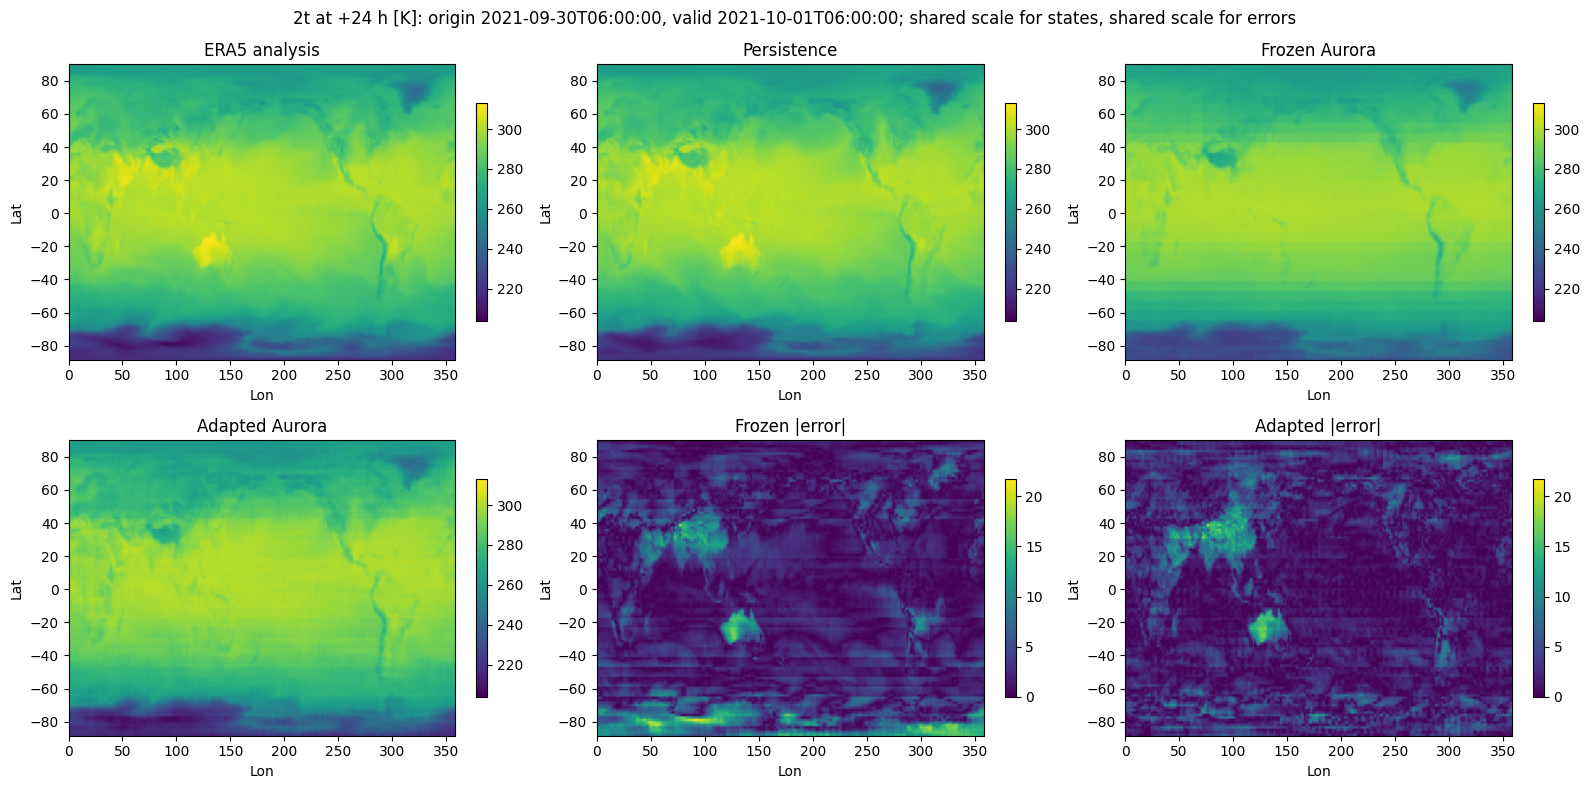

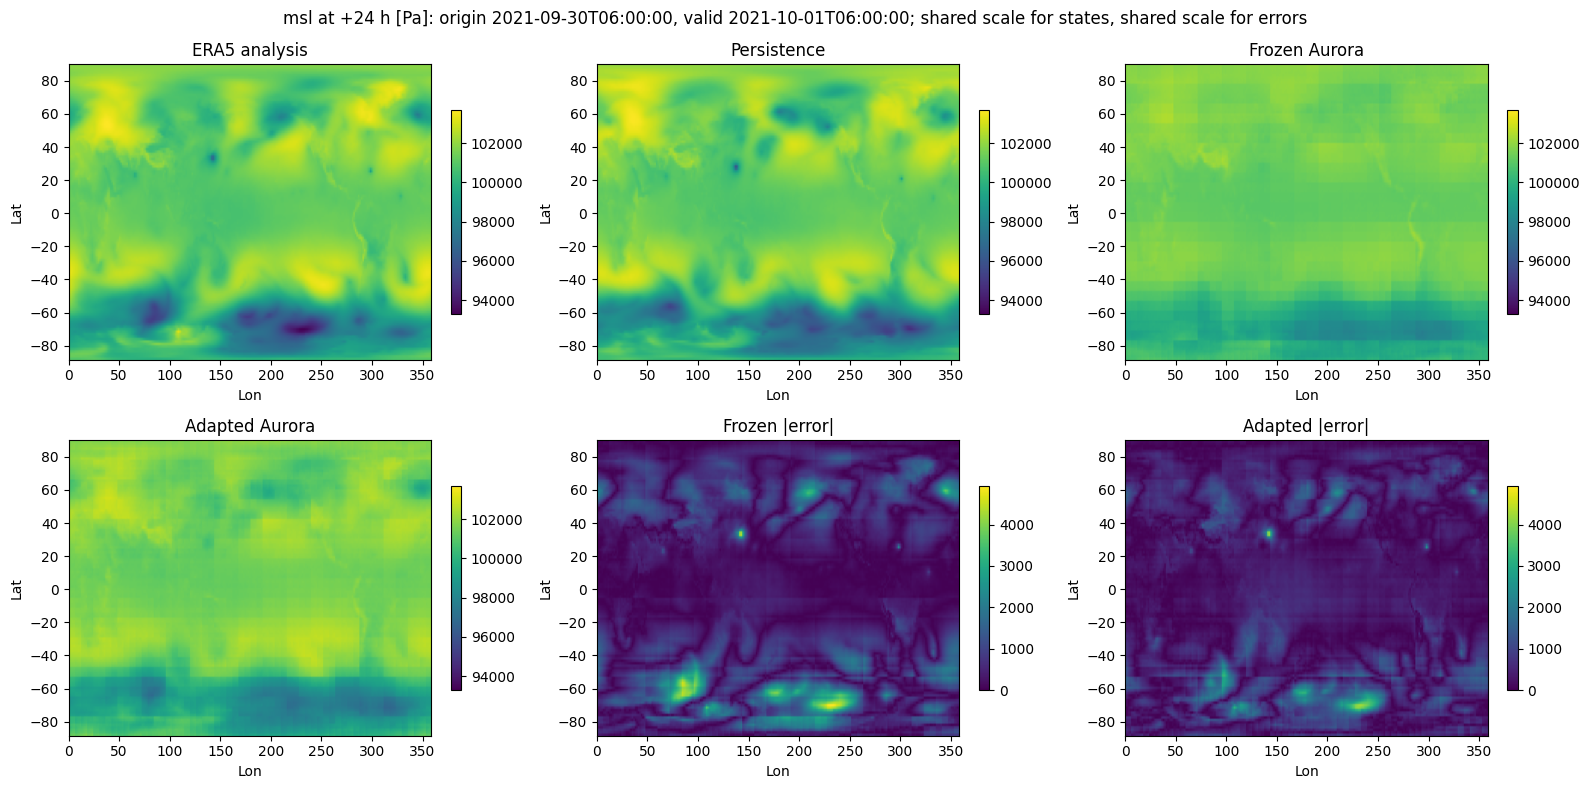

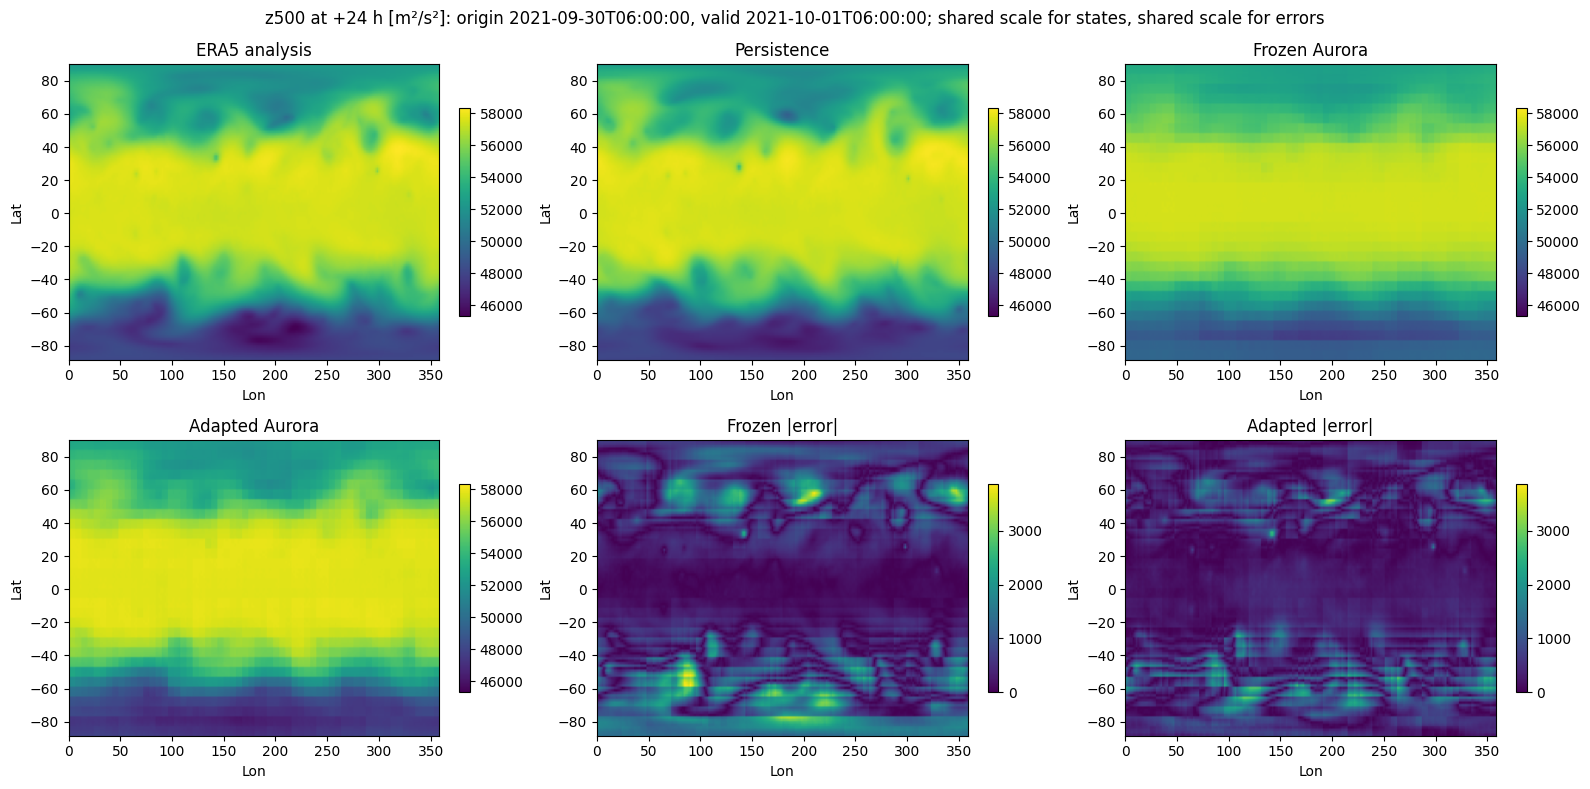

In [17]:
# @title Spatial maps at the longest evaluated lead
MAP_ORIGIN = TEST_ORIGINS[0]
MAP_STEPS = TEST_LEAD_STEPS

frozen_preds = forecast_from_origin(fresh_frozen_model, test_window, MAP_ORIGIN, MAP_STEPS)
adapted_preds = forecast_from_origin(adapted_model, test_window, MAP_ORIGIN, MAP_STEPS)
height = test_window["shape"][0] - (test_window["shape"][0] % PATCH_SIZE)
frozen_last = forecast_arrays(frozen_preds, test_window, MAP_ORIGIN)[-1]
adapted_last = forecast_arrays(adapted_preds, test_window, MAP_ORIGIN)[-1]
check_forecast_fields(frozen_last, test_window, height, "frozen map forecast")
check_forecast_fields(adapted_last, test_window, height, "adapted map forecast")

lat_map = test_window["lat"][:height]
lon_map = test_window["lon"]
extent = [lon_map[0], lon_map[-1], lat_map[-1], lat_map[0]]
truth_idx = MAP_ORIGIN + MAP_STEPS
z500_idx = LEVELS.index(500)
map_hours = MAP_STEPS * TIMESTEP_HOURS

spatial_cases = {
    "2t": {
        "truth": test_window["surf"]["2t"][truth_idx, :height],
        "persistence": test_window["surf"]["2t"][MAP_ORIGIN, :height],
        "frozen": frozen_last["surf"]["2t"],
        "adapted": adapted_last["surf"]["2t"],
        "unit": "K",
    },
    "msl": {
        "truth": test_window["surf"]["msl"][truth_idx, :height],
        "persistence": test_window["surf"]["msl"][MAP_ORIGIN, :height],
        "frozen": frozen_last["surf"]["msl"],
        "adapted": adapted_last["surf"]["msl"],
        "unit": "Pa",
    },
    "z500": {
        "truth": test_window["atmos"]["z"][truth_idx, z500_idx, :height],
        "persistence": test_window["atmos"]["z"][MAP_ORIGIN, z500_idx, :height],
        "frozen": frozen_last["atmos"]["z"][z500_idx],
        "adapted": adapted_last["atmos"]["z"][z500_idx],
        "unit": "m²/s²",
    },
}

for name, case in spatial_cases.items():
    frozen_err = np.abs(case["frozen"] - case["truth"])
    adapted_err = np.abs(case["adapted"] - case["truth"])
    # One colour scale for the four state panels and a second, shared one for both error panels,
    # so equal colours mean equal values across the panels being compared.
    state_lo = min(float(np.min(case[k])) for k in ("truth", "persistence", "frozen", "adapted"))
    state_hi = max(float(np.max(case[k])) for k in ("truth", "persistence", "frozen", "adapted"))
    err_hi = max(float(np.max(frozen_err)), float(np.max(adapted_err)))
    fields = [
        ("ERA5 analysis", case["truth"], (state_lo, state_hi)),
        ("Persistence", case["persistence"], (state_lo, state_hi)),
        ("Frozen Aurora", case["frozen"], (state_lo, state_hi)),
        ("Adapted Aurora", case["adapted"], (state_lo, state_hi)),
        ("Frozen |error|", frozen_err, (0.0, err_hi)),
        ("Adapted |error|", adapted_err, (0.0, err_hi)),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, (title, field, (vmin, vmax)) in zip(axes.ravel(), fields, strict=True):
        im = ax.imshow(field, extent=extent, aspect="auto", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel("Lon")
        ax.set_ylabel("Lat")
        plt.colorbar(im, ax=ax, fraction=0.026)
    fig.suptitle(
        f"{name} at +{map_hours} h [{case['unit']}]: origin {test_window['times'][MAP_ORIGIN]}, "
        f"valid {test_window['times'][truth_idx]}; shared scale for states, shared scale for errors"
    )
    plt.tight_layout()
    plt.savefig(produced(OUTPUT_ROOT / "figures" / f"spatial_{map_hours}h_{name}.png"), dpi=140, bbox_inches="tight")
    plt.show()

# 18. New-origin forecast

The rollout length is `FUTURE_FORECAST_STEPS` (24 hours by default, up to 48 hours). It is separate from the scored `MAX_LEAD_STEPS`, because no reference analysis exists for these valid times.

The final two analyses of the test window are now treated as the initial condition for a forecast extending beyond the supplied reference period.

Because the future analyses are not part of the sample:

**evaluation status = not measurable yet**

The summary reports **area-weighted** (cosine-latitude) global means. `forecast_fields.npz` is a **2 m temperature-only** sample export. It carries latitude, longitude, origin and valid times, lead hours and units, so every value can be placed. It is not a complete forecast state and not a georeferenced GIS product.

In [18]:
# @title Forecast beyond the available window
NEW_ORIGIN = test_window["n_steps"] - 1
future_preds = forecast_from_origin(adapted_model, test_window, NEW_ORIGIN, FUTURE_FORECAST_STEPS)
future_fields = forecast_arrays(future_preds, test_window, NEW_ORIGIN)
future_height = test_window["shape"][0] - (test_window["shape"][0] % PATCH_SIZE)
future_lat = test_window["lat"][:future_height]
for step, fields in enumerate(future_fields, start=1):
    check_forecast_fields(fields, test_window, future_height, f"future +{step * TIMESTEP_HOURS} h")
z500_idx = LEVELS.index(500)

def area_weighted_mean(field, lat):
    """Cosine-latitude area-weighted global mean of a (lat, lon) field."""
    field = np.asarray(field, dtype=np.float64)
    w = np.cos(np.deg2rad(np.asarray(lat, dtype=np.float64)))[:, None]
    return float((field * w).sum() / (w.sum() * field.shape[-1]))

future_start = datetime.fromisoformat(test_window["times"][NEW_ORIGIN])
future_valid = [
    (future_start + timedelta(hours=TIMESTEP_HOURS * step)).strftime("%Y-%m-%dT%H:%M:%S")
    for step in range(1, FUTURE_FORECAST_STEPS + 1)
]
future_summary = []
for step, fields in enumerate(future_fields, start=1):
    future_summary.append({
        "lead_hours": step * 6,
        "origin_time": test_window["times"][NEW_ORIGIN],
        "valid_time": future_valid[step - 1],
        "area_weighted_mean_2t_K": area_weighted_mean(fields["surf"]["2t"], future_lat),
        "area_weighted_mean_msl_Pa": area_weighted_mean(fields["surf"]["msl"], future_lat),
        "area_weighted_mean_z500_m2_s2": area_weighted_mean(fields["atmos"]["z"][z500_idx], future_lat),
        "evaluation_status": "not-measurable",
    })

future_df = pd.DataFrame(future_summary)
display(future_df)
future_df.to_csv(produced(OUTPUT_ROOT / "future" / "forecast_summary.csv"), index=False)

# A 2 m temperature-only sample export, with the coordinates and times needed to place every value.
np.savez_compressed(
    produced(OUTPUT_ROOT / "future" / "forecast_fields.npz"),
    **{
        f"lead_{(i+1)*6}h_2t": fields["surf"]["2t"]
        for i, fields in enumerate(future_fields)
    },
    latitude=np.asarray(future_lat, dtype=np.float64),
    longitude=np.asarray(test_window["lon"], dtype=np.float64),
    origin_time=np.asarray(test_window["times"][NEW_ORIGIN]),
    valid_times=np.asarray(future_valid),
    lead_hours=np.asarray([6 * (i + 1) for i in range(FUTURE_FORECAST_STEPS)]),
    units=np.asarray("K"),
    scope=np.asarray("2 m temperature only: a sample export, not a complete forecast state; not georeferenced GIS output"),
)

,lead_hours,origin_time,valid_time,area_weighted_mean_2t_K,area_weighted_mean_msl_Pa,area_weighted_mean_z500_m2_s2,evaluation_status
0,6,2021-10-01T18:00:00,2021-10-02T00:00:00,287.441590,101213.995402,55712.371210,not-measurable
1,12,2021-10-01T18:00:00,2021-10-02T06:00:00,287.058180,101266.881521,55746.359922,not-measurable
2,18,2021-10-01T18:00:00,2021-10-02T12:00:00,288.555231,101287.985982,55804.175632,not-measurable
3,24,2021-10-01T18:00:00,2021-10-02T18:00:00,289.184570,101254.441454,55836.586293,not-measurable


# 19. Export the LoRA adapter

The adapter contains only tensors permitted by the selected adaptation scope.

Canonical LoRA-only output is roughly 2 MB, far smaller than the 451 MB base checkpoint.

The manifest uses the DIMER Aurora carrier's adapter format (`org.valcorza.aurora-earth-system.adapter.v1`). It records the base model identity, including the **converted-base digests** that section 4 computed and verified, so an adapter cannot silently float across a different Aurora base. The carrier's consumer (`AuroraPipeline.from_artifact` / `load_artifact`) requires exactly those digests.

The manifest also records the source checkpoint and static-file digests, the adaptation scope, the tensor list, the training history and a digest of the selected adapter tensors. That tensor digest must equal the one frozen before the test.

In [19]:
# @title SafeTensors adapter export
from safetensors.torch import save_file, load_file

ARTIFACT_DIR = OUTPUT_ROOT / "artifacts" / "aurora_lora"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
adapter_path = ARTIFACT_DIR / ARTIFACT_WEIGHTS_NAME

wanted = set(adaptation["trainable_names"])
adapter_tensors = {
    k: v.detach().cpu().contiguous()
    for k, v in adapted_model.state_dict().items()
    if k in wanted
}
if sorted(adapter_tensors) != sorted(wanted):
    raise RuntimeError("adapter tensor scope mismatch")

save_file(adapter_tensors, str(produced(adapter_path)), metadata={"format": "pt"})

def build_adapter_manifest(adapter_path, tensor_names, adaptation, selected_state_sha256):
    """The carrier's adapter.v1 manifest. The converted-base digests are the ones verified in section 4."""
    return {
        "format": ARTIFACT_FORMAT,
        "format_version": ARTIFACT_FORMAT_VERSION,
        "base_model": {
            "id": MODEL_ID,
            "revision": MODEL_REVISION,
            "key": MODEL_KEY,
            "converted_sha256": dict(CONVERTED_SHA256),
            "checkpoint_name": CHECKPOINT_NAME,
            "checkpoint_sha256": CHECKPOINT_SHA256,
            "static_name": STATIC_NAME,
            "static_sha256": STATIC_SHA256,
        },
        "adapter": {
            "trainable": adaptation["trainable"],
            "n_tensors": len(tensor_names),
            "n_trainable": adaptation["n_trainable"],
            "n_parameters": adaptation["n_trainable"],
            "epochs": adaptation["epochs"],
            "best_epoch": adaptation["best_epoch"],
            "learning_rate": adaptation["learning_rate"],
            "seed": adaptation["seed"],
            "loss_scales": adaptation["loss_scales"],
            "selected_state_sha256": selected_state_sha256,
        },
        "history": adaptation["history"],
        "tensors": sorted(tensor_names),
        "files": [{
            "path": ARTIFACT_WEIGHTS_NAME,
            "bytes": Path(adapter_path).stat().st_size,
            "sha256": sha256_file(adapter_path),
        }],
        "metadata": {
            "producer": "DIMER weather and Earth-system forecasting workshop notebook",
            "run_id": RUN_ID,
            "base_conversion": "converted in this notebook from the pinned, pickle-audited source files; "
                               "both converted files matched the pinned digests",
            "training_static_fields": "static fields of the training windows (WeatherBench2 1.5° for the built-in sample)",
        },
    }

artifact_manifest = build_adapter_manifest(
    adapter_path,
    list(adapter_tensors),
    adaptation,
    tensor_state_digest(adapter_tensors),
)
if artifact_manifest["adapter"]["selected_state_sha256"] != frozen_record["selected_adapter"]["state_sha256"]:
    raise RuntimeError("the exported adapter tensors are not the ones frozen before the test")
produced(ARTIFACT_DIR / "manifest.json").write_text(
    json.dumps(artifact_manifest, indent=2), encoding="utf-8"
)

print(artifact_manifest["files"][0])

{'path': 'adapter.safetensors', 'bytes': 2173200, 'sha256': '23043cf9bceb9d8d6f9b5c3d3f2b30ca93c1118b681b0267e1bd695b2e50f4d3'}


# 20. Fresh-boundary reload verification

A valid artifact is more than a file that deserializes.

The notebook reconstructs a fresh LoRA-capable Aurora from the verified base checkpoint, loads exactly the declared adapter tensors, and repeats one fixed forecast.

Before loading, the notebook copies the artifact into a **fresh directory**. It applies the same static checks as the carrier's consumer: format and version, the pinned base including the converted-base digests, one weights file inside the directory, the declared scope and exact tensor list, and the file digest.

The adapted and reloaded outputs must both be **finite**, carry the expected valid time, and match within a strict numerical tolerance. A non-finite difference is a failure, not a pass.

In [20]:
# @title Fresh reload and parity
import math
import shutil
import tempfile

def check_adapter_manifest(root, manifest, expected_tensors):
    """The carrier consumer's static checks, plus the tensor scope and file digest.

    Format and version; the pinned base, including the converted-base digests; exactly one weights file,
    named adapter.safetensors, inside the artifact directory; a declared adaptation scope; the exact tensor
    list that scope may change; and the file's size and SHA-256. Returns the weights path and the scope."""
    root = Path(root)
    if manifest.get("format") != ARTIFACT_FORMAT:
        raise ValueError(f"artifact format {manifest.get('format')!r} != {ARTIFACT_FORMAT!r}")
    if manifest.get("format_version") != ARTIFACT_FORMAT_VERSION:
        raise ValueError(f"artifact format_version {manifest.get('format_version')!r} is not supported")
    base = manifest.get("base_model") or {}
    if (base.get("id"), base.get("revision")) != (MODEL_ID, MODEL_REVISION):
        raise ValueError("adapter base revision mismatch")
    if base.get("converted_sha256") != CONVERTED_SHA256:
        raise ValueError("artifact records different converted-base digests")
    if base.get("checkpoint_sha256") != CHECKPOINT_SHA256:
        raise ValueError("adapter base digest mismatch")
    files = manifest.get("files")
    if not isinstance(files, list) or len(files) != 1:
        raise ValueError("artifact manifest must list exactly one weights file")
    entry = files[0]
    if not isinstance(entry, dict) or entry.get("path") != ARTIFACT_WEIGHTS_NAME:
        raise ValueError(f"artifact weights file must be named {ARTIFACT_WEIGHTS_NAME!r}")
    weights = (root / entry["path"]).resolve()
    if weights.parent != root.resolve():
        raise ValueError("artifact weights file must sit inside the artifact directory")
    mode = (manifest.get("adapter") or {}).get("trainable")
    if mode not in ADAPTATION_MODES:
        raise ValueError("artifact adapter.trainable must be exactly 'lora' or 'lora+heads'")
    if not isinstance(manifest.get("tensors"), list) or sorted(manifest["tensors"]) != sorted(expected_tensors):
        raise ValueError("adapter tensor manifest mismatch")
    if not weights.is_file() or weights.stat().st_size != entry.get("bytes") or sha256_file(weights) != entry.get("sha256"):
        raise ValueError("adapter digest/size mismatch")
    return weights, mode

def parity_report(reference, candidate, tolerance):
    """Largest absolute difference per group, after requiring the same variables, shapes and finite values."""
    diffs = {}
    for group in ("surf", "atmos"):
        if set(reference[group]) != set(candidate[group]):
            raise ValueError(f"fresh reload parity failed: {group} variables differ")
        worst = 0.0
        for name in reference[group]:
            a = np.asarray(reference[group][name], dtype=np.float64)
            b = np.asarray(candidate[group][name], dtype=np.float64)
            if a.shape != b.shape:
                raise ValueError(f"fresh reload parity failed: {group}/{name} shapes {a.shape} != {b.shape}")
            if not (np.isfinite(a).all() and np.isfinite(b).all()):
                raise ValueError(f"fresh reload parity failed: {group}/{name} contains non-finite values")
            worst = max(worst, float(np.max(np.abs(a - b))) if a.size else 0.0)
        diffs[group] = worst
    if not all(math.isfinite(v) for v in diffs.values()) or max(diffs.values()) > tolerance:
        raise RuntimeError(f"fresh reload parity failed: surf={diffs['surf']}, atmos={diffs['atmos']}")
    return {
        "max_abs_surf_diff": diffs["surf"],
        "max_abs_atmos_diff": diffs["atmos"],
        "tolerance": tolerance,
        "status": "PASS",
    }

# Consume the artifact the way a downstream user would: copied into a fresh directory, checked, then loaded.
fresh_artifact_dir = Path(tempfile.mkdtemp(prefix="aurora_adapter_reload_"))
for name in (ARTIFACT_WEIGHTS_NAME, "manifest.json"):
    shutil.copy2(ARTIFACT_DIR / name, fresh_artifact_dir / name)

reloaded_model = build_aurora(use_lora=True)
manifest = json.loads((fresh_artifact_dir / "manifest.json").read_text(encoding="utf-8"))
declared_mode = (manifest.get("adapter") or {}).get("trainable")
expected_tensors = trainable_names(reloaded_model, declared_mode) if declared_mode in ADAPTATION_MODES else []
fresh_weights, _mode = check_adapter_manifest(fresh_artifact_dir, manifest, expected_tensors)

loaded = load_file(str(fresh_weights))
if sorted(loaded) != sorted(manifest["tensors"]):
    raise ValueError("adapter tensor manifest mismatch")

state = reloaded_model.state_dict()
for key, value in loaded.items():
    if tuple(value.shape) != tuple(state[key].shape):
        raise ValueError(f"{key}: adapter shape mismatch")
merged = dict(state)
merged.update({k: v.to(state[k].dtype) for k, v in loaded.items()})
reloaded_model.load_state_dict(merged, strict=True)
reloaded_model.eval()

VERIFY_ORIGIN = 1
VERIFY_STEPS = 1
a = forecast_arrays(forecast_from_origin(adapted_model, val_window, VERIFY_ORIGIN, VERIFY_STEPS), val_window, VERIFY_ORIGIN)[0]
b = forecast_arrays(forecast_from_origin(reloaded_model, val_window, VERIFY_ORIGIN, VERIFY_STEPS), val_window, VERIFY_ORIGIN)[0]

RELOAD_TOLERANCE = 1e-6
reload_report = parity_report(a, b, RELOAD_TOLERANCE)
reload_report["consumer_checks"] = {
    "fresh_directory": True,
    "format": manifest["format"],
    "converted_base_digests_match": True,
    "tensor_scope": declared_mode,
    "n_tensors": len(loaded),
}
surf_diff = reload_report["max_abs_surf_diff"]
atmos_diff = reload_report["max_abs_atmos_diff"]
print(reload_report)

{'max_abs_surf_diff': 0.0, 'max_abs_atmos_diff': 0.0, 'tolerance': 1e-06, 'status': 'PASS', 'consumer_checks': {'fresh_directory': True, 'format': 'org.valcorza.aurora-earth-system.adapter.v1', 'converted_base_digests_match': True, 'tensor_scope': 'lora', 'n_tensors': 80}}


# 21. BYOD contract

Full BYOD E2E mode requires **four NetCDF windows**:

- two training windows;
- one validation window;
- one independent test window.

The accepted schema uses:

### Coordinates

`time`, `latitude`, `longitude`, `level`

### Surface fields

`2t`, `10u`, `10v`, `msl`  
(or `surf_2t`, `surf_10u`, ...)

### Atmospheric fields

`t`, `u`, `v`, `q`, `z`  
(or `atmos_t`, ...)

### Static fields

`static_lsm`, `static_z`, `static_slt`

### Dimensions

Surface variables use `(time, latitude, longitude)`, atmospheric variables use `(time, level, latitude, longitude)`, and static fields use `(latitude, longitude)`. Any stored order is accepted, because every variable is transposed **by dimension name**. A variable with other or extra dimensions is refused. Each coordinate must be a 1-D coordinate along its own dimension.

### Units

`2t`, `t` K; `10u`, `10v`, `u`, `v` m/s; `msl` Pa; `q` kg/kg; `z` and `static_z` m²/s²; `static_lsm` a 0–1 fraction; `static_slt` a soil-type code. Values outside the plausible ranges in section 3 are refused: correct the units rather than widening the validator.

### Grid

All four windows use **one regular global grid** with identical coordinates:

- latitude from 90 to −90 (either direction), uniformly spaced, with H mod 4 in {0, 1};
- longitude in **[0, 360)**, uniformly spaced, covering the full circle, with W divisible by 4;
- H and W within 17..721 and 32..1440.

Regional and −180..180 grids are refused; shift a −180..180 grid and its fields to 0..360 first. All four windows must also carry identical static fields and exactly the 13 Aurora pressure levels, in the order listed in section 3.

### Role independence

- The four windows must not share any analysis time.
- Every training analysis must precede the validation window, and validation must precede test.
- No analysis's fields may repeat across roles under another timestamp.

The dataset manifest records each role's time span and name-independent content digest.

### Length

Each window holds 3..64 six-hourly analyses. The validation and test windows also need `2 + MAX_LEAD_STEPS` analyses: 6 for the default 24-hour evaluation, 10 for 48 hours. A shorter window is refused before any model is loaded.

### Example layout

```python
xr.Dataset(
    {"2t": (("time", "latitude", "longitude"), t2m), "t": (("time", "level", "latitude", "longitude"), temperature),
     "static_lsm": (("latitude", "longitude"), lsm), ...},
    coords={"time": times, "level": list(LEVELS), "latitude": lat, "longitude": lon},
).to_netcdf("train_1.nc")
```

BYOD results are labelled with your windows' names, periods and resolution. The built-in sample's headings (October 2021, 1.5°) describe only the default run.

### Data privacy

BYOD files are processed in the selected notebook runtime and are not sent to DIMER workers or APIs. A hosted notebook remains an external compute environment. Do not upload confidential, embargoed, proprietary, security-sensitive, or operational forecast data unless authorized.

# 22. Optional experiments

### A. LoRA versus LoRA + heads

Set:

`TRAINABLE = "lora+heads"`

and rerun from the top.

`lora+heads` trains the LoRA tensors, the decoder output heads **and the encoder token embeddings** (`encoder.surf_token_embeds`, `encoder.atmos_token_embeds`), not only the heads.

This changes the adaptation scope and must be selected on validation only. Do not compare several scopes on the test window and keep the best one.

### B. Longer rollouts

Forecast **generation** and forecast **evaluation** have different limits:

- **Scored leads:** one origin needs two history analyses plus one target analysis per lead. The built-in eight-analysis windows can therefore score at most **36 hours** (6 steps), from a single origin. A 42- or 48-hour evaluation has **no** reference target in the sample, so the preflight refuses it before any model loads.
- **Unscored forecasts:** `FUTURE_FORECAST_STEPS` (section 18) can roll out to 48 hours; its status is *not measurable*.

The activity cell below scores 6 h up to `ACTIVITY_LEAD_STEPS` × 6 h on **one fixed set of origins**, so every lead is compared on the same initial conditions. Changing `MAX_LEAD_STEPS` itself would also change which origins are scored. The activity writes to its own `activity/` directory, leaves every canonical result unchanged (it checks this), and is packaged separately in the report. With one or two origins, its results are diagnostic, not statistical evidence.

### C. Latitude bands

A useful extension is to break RMSE into:

- 90–60°N
- 60–30°N
- 30°N–30°S
- 30–60°S
- 60–90°S

One two-day held-out window cannot establish regional forecast quality.

In [21]:
# @title Optional activity: longer rollouts on one fixed set of origins
RUN_LONGER_ROLLOUT_ACTIVITY = False  # @param {type:"boolean"}
ACTIVITY_LEAD_STEPS = 6              # @param {type:"integer"}
ACTIVITY_WINDOW = "validation"       # @param ["validation", "test"]

activity_result = None
if not RUN_LONGER_ROLLOUT_ACTIVITY:
    print(
        "Activity not run. Tick RUN_LONGER_ROLLOUT_ACTIVITY, then run this cell (or Run all) to compare every lead "
        "from 6 h to ACTIVITY_LEAD_STEPS x 6 h on the same forecast origins."
    )
else:
    if ACTIVITY_WINDOW not in ("validation", "test"):
        raise ValueError("ACTIVITY_WINDOW must be 'validation' or 'test'")
    activity_window = {"validation": val_window, "test": test_window}[ACTIVITY_WINDOW]
    longest = activity_window["n_steps"] - HISTORY_STEPS
    if not 1 <= ACTIVITY_LEAD_STEPS <= min(8, longest):
        raise ValueError(
            f"ACTIVITY_LEAD_STEPS = {ACTIVITY_LEAD_STEPS} ({ACTIVITY_LEAD_STEPS * TIMESTEP_HOURS} h) is not measurable on the "
            f"{ACTIVITY_WINDOW} window: it has {activity_window['n_steps']} analyses, so the longest scored lead is "
            f"{longest * TIMESTEP_HOURS} h. Longer leads have no ERA5 target in this sample; use FUTURE_FORECAST_STEPS "
            "for an unscored forecast."
        )
    activity_origins = eval_origins(activity_window, ACTIVITY_LEAD_STEPS)

    # Snapshot the canonical results: files already written by this run, and the in-memory test summaries.
    canonical_files = {key: sha256_file(key) for key in PRODUCED if Path(key).is_file()}
    canonical_state = json.dumps(
        {"frozen_test": frozen_test["summary"], "adapted_test": adapted_test["summary"], "test_lead_steps": TEST_LEAD_STEPS},
        sort_keys=True, default=str,
    )

    activity_frozen = evaluate_model(fresh_frozen_model, activity_window, ACTIVITY_LEAD_STEPS, origins=activity_origins)
    activity_adapted = evaluate_model(adapted_model, activity_window, ACTIVITY_LEAD_STEPS, origins=activity_origins)

    if {key: sha256_file(key) for key in canonical_files} != canonical_files or json.dumps(
        {"frozen_test": frozen_test["summary"], "adapted_test": adapted_test["summary"], "test_lead_steps": TEST_LEAD_STEPS},
        sort_keys=True, default=str,
    ) != canonical_state:
        raise RuntimeError("the activity changed a canonical result; this must not happen")

    activity_hours = ACTIVITY_LEAD_STEPS * TIMESTEP_HOURS
    activity_dir = OUTPUT_ROOT / "activity" / f"longer_rollout_{activity_hours}h_{ACTIVITY_WINDOW}"
    activity_dir.mkdir(parents=True, exist_ok=True)
    activity_table = pd.DataFrame([
        {
            "lead_hours": int(lead[:-1]),
            "frozen_mean_rmse_ratio": activity_frozen["summary"][lead]["mean_skill"],
            "adapted_mean_rmse_ratio": activity_adapted["summary"][lead]["mean_skill"],
            "frozen_vars_beating_persistence": activity_frozen["summary"][lead]["variables_beating_persistence"],
            "adapted_vars_beating_persistence": activity_adapted["summary"][lead]["variables_beating_persistence"],
            "n_origins": activity_frozen["n_origins"],
        }
        for lead in activity_frozen["leads"]
    ])
    activity_receipt = {
        "activity": "longer rollouts on one fixed set of origins",
        "window_role": ACTIVITY_WINDOW,
        "window_name": activity_window["name"],
        "window_content_sha256": window_content_digest(activity_window),
        "lead_steps": ACTIVITY_LEAD_STEPS,
        "lead_hours": activity_hours,
        "origins": activity_origins,
        "origin_times": [activity_window["times"][o] for o in activity_origins],
        "canonical_results_unchanged": True,
        "evidence_status": "exploratory diagnostic; not the frozen canonical test result",
        "output_dir": str(activity_dir),
    }
    produced(activity_dir / "metrics.json").write_text(
        json.dumps({"receipt": activity_receipt, "frozen": activity_frozen, "adapted": activity_adapted}, indent=2),
        encoding="utf-8",
    )
    activity_table.to_csv(produced(activity_dir / "lead_table.csv"), index=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(activity_table["lead_hours"], activity_table["frozen_mean_rmse_ratio"], marker="o", label="frozen")
    ax.plot(activity_table["lead_hours"], activity_table["adapted_mean_rmse_ratio"], marker="o", label="adapted")
    ax.axhline(1.0, linestyle="--", label="persistence")
    ax.set_xlabel("Lead time [hours]")
    ax.set_ylabel("Mean RMSE ratio vs persistence")
    ax.set_title(f"Activity: {ACTIVITY_WINDOW} window, {len(activity_origins)} fixed origin(s), up to {activity_hours} h")
    ax.legend()
    plt.tight_layout()
    plt.savefig(produced(activity_dir / "lead_skill.png"), dpi=150, bbox_inches="tight")
    plt.show()

    print(activity_table.to_string(index=False))
    if ACTIVITY_WINDOW == "test":
        print("The test window was already inspected in section 15: treat this as exploratory, not a new held-out result.")
    print({k: activity_receipt[k] for k in ("window_role", "lead_hours", "origin_times", "canonical_results_unchanged")})
    activity_result = {"receipt": activity_receipt, "table": activity_table.to_dict("records")}

Activity not run. Tick RUN_LONGER_ROLLOUT_ACTIVITY, then run this cell (or Run all) to compare every lead from 6 h to ACTIVITY_LEAD_STEPS x 6 h on the same forecast origins.


# 23. Interpretation and operational limits

### Small checkpoint

This notebook uses Aurora's small debugging/testing checkpoint, not the production-scale 1.3B model.

### Resolution shift

Every built-in metric is measured at **1.5°**, not the 0.25° training grid.

### ERA5 is the reference

ERA5 is a reanalysis produced by assimilating observations into a numerical weather model. Error here means error relative to ERA5, not error relative to direct observations.

### Deterministic forecast

This workflow provides no:

- ensemble spread;
- calibrated forecast uncertainty;
- probability of threshold exceedance; or
- confidence interval.

### One tiny held-out period

Two days from October 2021 cannot establish general forecast skill across:

- seasons;
- tropical cyclones;
- blocking events;
- regional extremes;
- different analysis products.

### Operational boundary

Do not use this notebook's output alone to issue or inform:

- public weather warnings;
- aviation decisions;
- marine routing;
- emergency management;
- energy dispatch;
- agricultural advisories; or
- other consequential weather decisions.

An operational workflow requires representative verification, uncertainty treatment, monitoring, appropriate fallback procedures, and qualified meteorological review.

# 24. Exercises

### Exercise 1 — persistence

Before viewing the neural forecast, which atmospheric fields should persistence handle well at six hours?

### Exercise 2 — resolution transfer

Why does changing from 0.25° to 1.5° alter the meaning of a 4×4 model token even though the input variables and units are unchanged?

### Exercise 3 — weighted RMSE

Why does cosine-latitude weighting matter for a regular lat/lon grid?

### Exercise 4 — adaptation

If one-step validation loss improves, must the 24-hour autoregressive forecast also improve? Why not?

### Exercise 5 — deployment

What additional verification would you require before using an adapted Earth-system model for a Philippine forecasting application?

## 25. Export provenance and report bundle

The bundle contains **only the files this run produced**, listed with their SHA-256 in `run_inventory.json`, and its name carries the run ID. Files that earlier runs left in `OUTPUT_DIR` stay on disk but are not packaged as this run's results. If you run the optional activity after this cell, run this cell again to package it.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [22]:
# @title Final provenance export
import zipfile
from datetime import timezone

runtime_report = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "device": DEVICE,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}

experiment_manifest = {
    "notebook_spec": "2.1",
    "notebook_profile": "E2E",
    "notebook_mode": "WORKSHOP",
    "workshop_revision": "0.1.0-candidate",
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "model": {
        "id": MODEL_ID,
        "revision": MODEL_REVISION,
        "checkpoint": CHECKPOINT_NAME,
        "bytes": CHECKPOINT_BYTES,
        "sha256": CHECKPOINT_SHA256,
        "parameters": PARAMETER_COUNT,
        "small_debug_checkpoint": True,
    },
    "run_id": RUN_ID,
    "base_conversion": base_receipt,
    "dataset": dataset_manifest,
    "freeze": {
        "path": str(freeze_path),
        "experiment_sha256": frozen_record["experiment_sha256"],
        "test_lead_steps": TEST_LEAD_STEPS,
        "test_origins": TEST_ORIGINS,
    },
    "future_forecast": {"steps": FUTURE_FORECAST_STEPS, "evaluation_status": "not-measurable"},
    "optional_outputs": {
        "longer_rollout_activity": (activity_result or {}).get("receipt", "not run"),
    },
    "adaptation": {
        k: v for k, v in adaptation.items()
        if k != "trainable_names"
    },
    "test": {
        "comparison": comparison.to_dict("records"),
        "frozen_seconds": frozen_test_seconds,
        "adapted_seconds": adapted_test_seconds,
    },
    "artifact": artifact_manifest,
    "reload": reload_report,
    "runtime": runtime_report,
    "standalone_contract": {
        "git_clone_required": False,
        "dimer_source_runtime_fetch_required": False,
        "dimer_worker_required": False,
        "credentials_required": False,
        "default_upload_required": False,
    },
    "candidate_release_gates": [
        "fresh T4 Run all qualification",
        "reconcile anonymous xarray WeatherBench2 acquisition with the live DIMER 57-object digest-pinned data path",
        "record peak VRAM and wall times for the exact released notebook",
        "hosted qualification of BYOD NetCDF, the longer-rollout activity, and consumption of the exported adapter "
        "by aurora_earth_system_pipeline.AuroraPipeline.from_artifact",
    ],
    "evidence_scope": (
        "small Aurora checkpoint, real ERA5 via WeatherBench2 at out-of-distribution 1.5° resolution, "
        "two training windows, one validation window, one independent two-day test window"
    ),
}

produced(OUTPUT_ROOT / "provenance" / "experiment_manifest.json").write_text(
    json.dumps(experiment_manifest, indent=2, default=str),
    encoding="utf-8",
)
produced(OUTPUT_ROOT / "workshop_summary.json").write_text(
    json.dumps({
        "model": "Aurora 0.25° small pretrained",
        "test_comparison": comparison.to_dict("records"),
        "best_epoch": adaptation["best_epoch"],
        "trainable_parameters": adaptation["n_trainable"],
        "adapter_bytes": adapter_path.stat().st_size,
        "reload": reload_report,
    }, indent=2, default=str),
    encoding="utf-8",
)

def write_report_bundle(bundle_path, root, produced_paths, run_id):
    """Zip exactly the files this run produced, plus run_inventory.json with their sizes and SHA-256.
    Files from earlier runs that remain in OUTPUT_DIR are left on disk and are not packaged."""
    root = Path(root).resolve()
    inventory = []
    for path in sorted({Path(p).resolve() for p in produced_paths}):
        if not path.is_file():
            continue
        try:
            rel = path.relative_to(root).as_posix()
        except ValueError as exc:
            raise ValueError(f"{path} is outside the output directory {root}") from exc
        inventory.append({"path": rel, "bytes": path.stat().st_size, "sha256": sha256_file(path)})
    with zipfile.ZipFile(bundle_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for entry in inventory:
            zf.write(root / entry["path"], entry["path"])
        zf.writestr("run_inventory.json", json.dumps({"run_id": run_id, "files": inventory}, indent=2))
    return inventory

bundle = str(Path(OUTPUT_DIR).resolve()) + f"_DIMER_Aurora_Weather_Workshop_Report_{RUN_ID}.zip"
bundle_inventory = write_report_bundle(bundle, OUTPUT_ROOT, list(PRODUCED), RUN_ID)

print({
    "experiment_manifest": str(OUTPUT_ROOT / "provenance" / "experiment_manifest.json"),
    "report_bundle": bundle,
    "report_sha256": sha256_file(bundle),
    "files_in_bundle": len(bundle_inventory),
    "optional_outputs": sorted(e["path"] for e in bundle_inventory if e["path"].startswith("activity/")) or "none",
})

{'experiment_manifest': 'outputs/provenance/experiment_manifest.json', 'report_bundle': '/content/outputs_DIMER_Aurora_Weather_Workshop_Report_20260928T214804Z-851.zip', 'report_sha256': '057b5ce6995974c9d3a36e2cf84be2cb90e13f91119c8d57d5e507ace8c97c8a', 'files_in_bundle': 30, 'optional_outputs': 'none'}


# 26. Troubleshooting

| Symptom | Likely cause | Corrective action |
|---|---|---|
| CUDA unavailable | CPU runtime selected | switch to a T4-class GPU before running from the top |
| Aurora checkpoint digest mismatch | changed/incomplete model asset | remove cached checkpoint and retry; never bypass the pin |
| anonymous GCS/Zarr open fails | transient WeatherBench2/GCS or package issue | retry in a fresh runtime; preserve the same store and role chunks |
| wrong pressure levels | incompatible dataset | provide exactly the 13 Aurora levels |
| longitude count rejected | grid incompatible with patch size | use a global grid whose longitude count is divisible by four |
| latitude count rejected | patch geometry mismatch | use a global grid with H mod 4 in {0,1} |
| temperature/pressure range rejection | wrong units or corrupt data | correct source units rather than widening the validator |
| frozen model loses to persistence | 1.5° OOD setup | treat as an expected scientific result, not an execution failure |
| LoRA validation worsens | adaptation did not help | epoch 0 remains a valid selection |
| test improves after tuning on it | test leakage | restart; choose configuration only from training/validation |
| fresh reload mismatch | artifact/base mismatch or nondeterministic execution issue | stop and inspect model/artifact identity |
| BYOD path missing | full E2E role set incomplete | provide all four NetCDF role paths |
| `MAX_LEAD_STEPS ... cannot be evaluated` | the validation/test windows lack `2 + MAX_LEAD_STEPS` analyses | lower `MAX_LEAD_STEPS` (at most 6 on the built-in sample), supply longer windows, or use `FUTURE_FORECAST_STEPS` for an unscored forecast |
| roles share analysis times / same fields / chronological policy | BYOD windows overlap or are out of order | give each role different, non-overlapping periods: train before validation before test |
| coordinates or static fields differ from train-1 | the four windows are not on one grid | regrid all windows to one global grid with identical static fields |
| longitudes must lie in [0, 360) / cover the full circle | −180..180 or regional grid | shift longitudes to 0..360 with their fields; regional grids are not supported |
| `... has dimensions ...; expected exactly ...` | a NetCDF variable has other or extra dimensions | store surface/atmospheric/static variables on the documented dimensions |
| live state no longer matches the frozen experiment | a setting, the data or the adapter changed after section 14 | re-run from section 14 to record a new experiment |
| forecast `contains non-finite values` / valid time mismatch | invalid model output | stop and inspect the runtime; the result is not scored as a poor forecast |
| converted base files do not match the pinned digests | the runtime did not reproduce the carrier's base | stop; do not export or reuse an adapter from this runtime |

A clear refusal is preferable to silently changing the Earth-system forecasting problem.

## Try it yourself — one controlled change

Use the same discipline as the main experiment:

**Predict → change one variable → rerun → observe → explain**

Use the **Longer rollouts** activity in section 22: tick `RUN_LONGER_ROLLOUT_ACTIVITY` and run that cell. You can tick it before **Run all**, so the export in section 25 packages it; if you run it later, run the export cell again. Before running it, predict how forecast error should change as lead time increases. Then compare the lead-time error curve with persistence and explain where the model gains or loses skill.

The activity scores every lead on **one fixed set of origins**, so the leads share initial conditions. On the built-in sample, 36 hours is the longest measurable lead, and it comes from a single origin. It writes only to `activity/` and checks that the frozen canonical results are unchanged.

Keep this exercise separate from the frozen canonical test result. If you use validation or an optional post-test exercise to explore a setting, do not retroactively present the changed setting as the pre-registered canonical result.


## Self-paced checkpoint

Before reading the sample interpretation, answer in your own words:

1. What was the model or system asked to do?
2. Which baseline/reference tells you whether the model added useful capability?
3. What is the most important failure mode or tradeoff visible in this notebook?
4. What would you need to test before applying the result to a different dataset or operational setting?

<details>
<summary><b>Show a sample interpretation</b></summary>

Forecast quality must be read by lead time and against persistence, not from a single map or aggregate number. A visually plausible field can still have substantial spatial error, and this weather-forecasting exercise is not a climate projection.

A complete answer should cite the outputs from **your run**, because small numerical differences can occur across supported runtimes.

</details>


## Write an evidence-based conclusion

Use the outputs from your run rather than declaring a universal winner.

1. **State the question.** What capability or comparison did this notebook test?
2. **Report the primary result.** Compare the relevant model/system with its baseline or reference on the held-out or otherwise designated evaluation data.
3. **Add supporting evidence.** Include the most informative secondary metric, error pattern, qualitative diagnostic, or disagreement.
4. **Account for cost or complexity.** Mention runtime, model footprint, extra stages, or adaptation when they materially affect the comparison.
5. **State the limits.** Say what this dataset, split, model revision, and configuration do—and do not—support.

Report the frozen test result against persistence, describe lead-time error growth and at least one spatial error pattern, note the effect of adaptation if used, and keep the conclusion specific to the ERA5/WeatherBench2 windows and Aurora configuration evaluated here.


# Glossary

| Term | Meaning |
|---|---|
| **Analysis** | Estimated atmospheric state used as model initial condition/reference |
| **Reanalysis** | Retrospective analysis produced with a fixed assimilation/model system, e.g. ERA5 |
| **Forecast origin** | Latest observed analysis from which a forecast starts |
| **Lead time** | Time between forecast origin and predicted valid time |
| **Persistence** | Baseline that carries the latest analysis forward unchanged |
| **Autoregressive rollout** | Feed each predicted state into the next forecast step |
| **Latitude-weighted RMSE** | RMSE weighted by cos(latitude) to account for grid-cell area |
| **z500** | Geopotential at 500 hPa, a common mid-tropospheric diagnostic |
| **LoRA** | Low-rank adaptation of selected model projections |
| **Domain shift** | Difference between pretraining and deployment distributions |
| **Resolution shift** | Change in physical meaning/scale of model grid cells |
| **ERA5** | ECMWF global atmospheric reanalysis used here as reference |
| **WeatherBench2** | Benchmark/data infrastructure distributing standardized weather datasets |
| **Sample-sanity evidence** | Evidence that a bounded tutorial workflow executes; not operational verification |

In [23]:
# @title Run-all completion summary
completion = {
    "notebook_spec": "2.1",
    "profile": "E2E",
    "mode": "WORKSHOP",
    "model": "microsoft/aurora — AuroraSmallPretrained",
    "model_revision": MODEL_REVISION,
    "run_id": RUN_ID,
    "device": DEVICE,
    "dataset": dataset_manifest["source"],
    "tutorial_resolution_degrees": dataset_manifest["resolution_degrees"],
    "training_resolution_degrees": 0.25,
    "best_epoch": adaptation["best_epoch"],
    "trainable_parameters": adaptation["n_trainable"],
    "adapter_bytes": adapter_path.stat().st_size,
    "reload_status": reload_report["status"],
    "evaluation_lead_hours": TEST_LEAD_STEPS * TIMESTEP_HOURS,
    "longer_rollout_activity": "run" if activity_result else "not run",
    "output_directory": str(OUTPUT_ROOT.resolve()),
    "release_status": "candidate",
}
display(pd.Series(completion, name="value").to_frame())

print(
    "Notebook complete. Interpret all metrics as sample-sanity evidence on the small Aurora checkpoint "
    "at an out-of-distribution 1.5° grid, not as operational or native-resolution Aurora skill."
)

,value
notebook_spec,2.1
profile,E2E
mode,WORKSHOP
model,microsoft/aurora — AuroraSmallPretrained
model_revision,a96afd7ee6d65e3bd2d476f3be798a25a56f2296
run_id,20260928T214804Z-851
device,cuda
dataset,ERA5 via WeatherBench2 1.5°
tutorial_resolution_degrees,1.5
training_resolution_degrees,0.25


Notebook complete. Interpret all metrics as sample-sanity evidence on the small Aurora checkpoint at an out-of-distribution 1.5° grid, not as operational or native-resolution Aurora skill.


# Troubleshooting

| What you see | Likely cause | What to do |
|---|---|---|
| Accelerator unavailable or the model is unexpectedly slow | The runtime does not match the documented resource envelope | Select the documented accelerator/runtime, start a fresh session, and run the notebook top-to-bottom. |
| Package/version or stale-module error after installation | The hosted kernel had incompatible libraries imported before the pinned install | Start a fresh runtime and choose **Run all** before importing extra packages. Do not bypass the notebook's version checks. |
| Model/sample digest or size verification fails | A download is incomplete or upstream bytes differ from the pinned artifact | Remove the affected runtime cache/download and rerun. Do not disable the integrity check. |
| Out-of-memory / session restart | Too many large models or intermediate objects are resident | Use the default execution tier, follow the notebook's release/unload steps, and avoid enabling optional heavy branches together. |
| BYOD validation fails | User input does not satisfy the documented schema, shape, labels, or limits | Read the validation message, correct the stated field/shape/format, and rerun the BYOD branch. |
| Your numbers differ slightly from the example/expectation | Supported hardware or library execution can introduce small numerical variation | Compare the qualitative pattern, metric definitions, split, and model revision before treating the difference as meaningful. |
